[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jhavierc/NLP_taller_1/blob/main/notebook_taller_2.ipynb)

> **Nota sobre Google Colab:** este cuaderno esta pensado para 2 GPU Tesla T4 (Kaggle), igual que taller 1 y taller 3. En Colab gratuito (1 sola GPU) cambia `requested_gpus=1` en el PASO 02 antes de ejecutar; el resto del cuaderno funciona igual, solo sin `DataParallel` entre dos dispositivos y con tiempos de entrenamiento distintos a los reportados en el informe final.

# Taller 2 — Reconocimiento de entidades clínicas con un encoder Transformer

**Carlos Javier Cepeda, David Salamanca y José Milciades Ordoñez**

En este taller continuamos el trabajo realizado en el Taller 1 utilizando el mismo conjunto de datos, la misma partición y la misma tarea de reconocimiento de entidades clínicas. Nuestro objetivo es reemplazar la Bi-LSTM por un encoder Transformer implementado desde cero y analizar su comportamiento bajo condiciones experimentales comparables.

Construimos los principales componentes del encoder, como la atención multi-cabeza, las conexiones residuales y las capas de normalización, y clasificamos cada token según su etiqueta BIO. De esta manera, estudiamos si un Transformer entrenado desde cero logra mejorar el F1 obtenido por la línea base recurrente.

También consideramos una restricción fundamental: el corpus disponible es relativamente pequeño para entrenar un Transformer desde cero. Estos modelos tienen más parámetros y requieren una cantidad considerable de datos para aprender representaciones lingüísticas estables. Por ello, además de comparar el rendimiento, analizamos cómo el tamaño del corpus, el desbalance de las etiquetas y la complejidad del modelo afectan los resultados.

Mantenemos el conjunto de prueba separado hasta la evaluación final y utilizamos varias semillas para medir la estabilidad de las conclusiones.


### PASO 01 — Dependencias y modelo lingüístico

Instalamos las bibliotecas que necesita nuestro cuaderno y el modelo español pequeño de spaCy.

In [1]:
# PASO 01 — Dependencias
# Versiones de spaCy y pandas iguales a la línea base guardada del taller 1.
import sys, subprocess, importlib.util

packages = ['spacy==3.8.14', 'pandas==2.3.3', 'pyarrow>=14', 'requests>=2.31', 'tqdm>=4.66']
if importlib.util.find_spec('torch') is None:
    packages.append('torch>=2.2,<3')
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *packages])
model_url = ('https://github.com/explosion/spacy-models/releases/download/'
             'es_core_news_sm-3.8.0/es_core_news_sm-3.8.0-py3-none-any.whl')
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', model_url])
print('PASO 01 OK. Dependencias instaladas. Continúa con la 02.')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 57.7 MB/s eta 0:00:00
PASO 01 OK. Dependencias instaladas. Continúa con la 02.


### PASO 02 — Configuración, GPU y reproducibilidad

Definimos todos los hiperparámetros, las etiquetas BIO, los identificadores POS, las semillas y las rutas de salida. Comprobamos que Kaggle detecte las dos GPU solicitadas y creamos el envoltorio `DataParallel` para repartir cada lote entre GPU 0 y GPU 1. También configuramos CUDA, semillas y memoria para registrar y reducir la variabilidad entre ejecuciones.

In [2]:
# PASO 02 — Partición fija y tres semillas: seis entrenamientos de hasta 20 épocas
import os, json, time, random, math, hashlib, platform, traceback
from pathlib import Path
from collections import Counter
import numpy as np
import pandas as pd
import requests, spacy, torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from tqdm.auto import tqdm

CFG = dict(split_seed=42, training_seeds=[42, 123, 2026], fraction=1.0, validation_fraction=0.20,
           epochs=20, patience=5, batch_size=16, max_tokens=128,
           embedding_dim=64, pos_dim=16, d_model=128, num_heads=4, layers=2, ff_dim=256,
           dropout=0.25, learning_rate=0.001, cpu_threads=min(4, os.cpu_count() or 1),
           spacy_model='es_core_news_sm', class_weights=True,
           run_final_test=True, final_test_variant=None, final_test_seed=42, requested_gpus=2, allow_cpu_for_debug=False)
assert CFG['d_model'] % CFG['num_heads'] == 0
assert CFG['layers'] >= 1 and CFG['ff_dim'] > 0
assert 0 < CFG['fraction'] <= 1
assert 0 < CFG['validation_fraction'] < 1, 'Usa validation_fraction=0.20 para reservar el 20 %.'
assert isinstance(CFG['split_seed'], int) and 0 <= CFG['split_seed'] < 2**32
assert (isinstance(CFG['training_seeds'], list) and len(CFG['training_seeds']) >= 2
        and all(type(s) is int and 0 <= s < 2**32 for s in CFG['training_seeds'])
        and len(set(CFG['training_seeds'])) == len(CFG['training_seeds'])), 'Usa al menos dos semillas enteras distintas.'
random.seed(CFG['split_seed']); np.random.seed(CFG['split_seed']); torch.manual_seed(CFG['split_seed'])
torch.set_num_threads(CFG['cpu_threads'])
assert CFG['requested_gpus'] in (1, 2), 'requested_gpus debe ser 1 o 2.'
available_gpus = torch.cuda.device_count() if torch.cuda.is_available() else 0
if available_gpus == 0 and CFG['allow_cpu_for_debug']:
    device_ids = []
    device = torch.device('cpu')
    print('AVISO: modo de depuración CPU explícito; NO valida CUDA ni las dos T4.')
elif available_gpus < CFG['requested_gpus']:
    raise RuntimeError(f'PASO 02: se requieren {CFG["requested_gpus"]} GPU CUDA y se detectaron '
                       f'{available_gpus}. En Kaggle selecciona GPU T4 x2 y reinicia la sesión. '
                       'Para usar deliberadamente una sola GPU cambia requested_gpus=1.')
else:
    device_ids = list(range(CFG['requested_gpus']))
    device = torch.device(f'cuda:{device_ids[0]}')
    torch.cuda.set_device(device)
    torch.cuda.manual_seed_all(CFG['split_seed'])
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
    torch.backends.cuda.matmul.allow_tf32 = False

def synchronize_devices():
    """Bloquea la ejecución hasta que todas las GPU usadas terminen sus operaciones
    pendientes (barrera de sincronización). La usamos antes/después de medir tiempos,
    porque las llamadas a CUDA son asíncronas y, sin sincronizar, los tiempos medidos
    en CPU no reflejarían el trabajo real de la GPU."""
    for index in device_ids:
        torch.cuda.synchronize(index)

def move_batch(batch):
    """Mueve todos los tensores de un lote (dict de tensores) al dispositivo de cómputo
    (GPU o CPU) definido en `device`."""
    # lengths se reparte con DataParallel y define la máscara de atención.
    return {key: tensor.to(device, non_blocking=(device.type == 'cuda'))
            for key, tensor in batch.items()}

def unwrap(model):
    """Devuelve el modelo real dentro de un envoltorio `nn.DataParallel`, o el modelo
    tal cual si no está envuelto. La usamos para acceder a atributos del modelo
    (por ejemplo `pos_embedding`) o para guardar/cargar sus pesos sin el prefijo
    que agrega DataParallel."""
    return model.module if isinstance(model, nn.DataParallel) else model

def prepare_model(base):
    """Envía el modelo al dispositivo de cómputo y, si hay más de una GPU disponible,
    lo envuelve en `nn.DataParallel` para repartir cada lote entre todas las GPU
    (`device_ids`) durante el forward y el backward."""
    base = base.to(device)
    return nn.DataParallel(base, device_ids=device_ids, output_device=device_ids[0]) if len(device_ids) > 1 else base

def memory_report():
    """Devuelve, para cada GPU usada, el pico de memoria asignada y reservada (en MB)
    desde el último `reset_peak_memory_stats`. Sirve para diagnosticar uso de memoria
    por época sin tener que inspeccionar manualmente cada GPU."""
    return [{'id': index, 'name': torch.cuda.get_device_name(index),
             'peak_allocated_mb': torch.cuda.max_memory_allocated(index) / 2**20,
             'peak_reserved_mb': torch.cuda.max_memory_reserved(index) / 2**20}
            for index in device_ids]

gpu_info = {'available_count': available_gpus, 'used_count': len(device_ids),
            'device_ids': device_ids, 'parallelism': 'DataParallel' if len(device_ids) > 1 else str(device),
            'precision': 'float32', 'cuda_version': torch.version.cuda,
            'cudnn_version': torch.backends.cudnn.version(),
            'devices': [{'id': index, 'name': torch.cuda.get_device_name(index),
                         'total_memory_gb': torch.cuda.get_device_properties(index).total_memory / 2**30}
                        for index in device_ids]}
print('GPU_CONFIGURADAS:', json.dumps(gpu_info, indent=2), flush=True)
ROOT = Path('/kaggle/working') if Path('/kaggle/working').exists() else Path.cwd()
WORK = ROOT / 'spaccc_transformer'
WORK.mkdir(parents=True, exist_ok=True)
RUN = WORK / (time.strftime('%Y%m%d_%H%M%S') + '_' + str(time.time_ns())[-6:])
RUN.mkdir()
CACHE = WORK / 'cache'; CACHE.mkdir(exist_ok=True)
LABELS = ['CHEMICAL', 'DISEASE', 'PROCEDURE', 'PROTEIN', 'SYMPTOM']
TAGS = ['O'] + [f'{prefix}-{label}' for label in LABELS for prefix in ('B', 'I')]
tag_to_ix = {tag: i for i, tag in enumerate(TAGS)}
POS = ['<PAD>', '<UNK>', 'ADJ', 'ADP', 'ADV', 'AUX', 'CCONJ', 'DET', 'INTJ',
       'NOUN', 'NUM', 'PART', 'PRON', 'PROPN', 'PUNCT', 'SCONJ', 'SYM', 'VERB', 'X', 'SPACE']
pos_to_ix = {p: i for i, p in enumerate(POS)}
IGNORE = -100  # Solo padding y posiciones no evaluables. O=0 sí se aprende.
START = time.perf_counter()
REPORT = {'config': CFG.copy(), 'run_dir': str(RUN), 'device': str(device), 'gpu': gpu_info,
          'cpu': {'logical_cores': os.cpu_count(), 'machine': platform.machine(),
                  'torch_threads': torch.get_num_threads()},
          'versions': {'python': platform.python_version(), 'torch': str(torch.__version__),
                       'spacy': spacy.__version__, 'pandas': pd.__version__}}
(RUN / 'config.json').write_text(json.dumps(REPORT, indent=2), encoding='utf-8')
print('PASO 02 OK:', json.dumps(REPORT, indent=2))
REPORT['architecture'] = 'ClinicalTransformer-from-scratch-v1'
REPORT['test_selection_rule'] = 'Mayor F1 medio de validación; empate favorece sin_pos; semilla fija 42.'
(RUN / 'config.json').write_text(json.dumps(REPORT, indent=2), encoding='utf-8')


GPU_CONFIGURADAS: {
  "available_count": 2,
  "used_count": 2,
  "device_ids": [
    0,
    1
  ],
  "parallelism": "DataParallel",
  "precision": "float32",
  "cuda_version": "12.8",
  "cudnn_version": 91002,
  "devices": [
    {
      "id": 0,
      "name": "Tesla T4",
      "total_memory_gb": 14.56219482421875
    },
    {
      "id": 1,
      "name": "Tesla T4",
      "total_memory_gb": 14.56219482421875
    }
  ]
}
PASO 02 OK: {
  "config": {
    "split_seed": 42,
    "training_seeds": [
      42,
      123,
      2026
    ],
    "fraction": 1.0,
    "validation_fraction": 0.2,
    "epochs": 20,
    "patience": 5,
    "batch_size": 16,
    "max_tokens": 128,
    "embedding_dim": 64,
    "pos_dim": 16,
    "d_model": 128,
    "num_heads": 4,
    "layers": 2,
    "ff_dim": 256,
    "dropout": 0.25,
    "learning_rate": 0.001,
    "cpu_threads": 4,
    "spacy_model": "es_core_news_sm",
    "class_weights": true,
    "run_final_test": true,
    "final_test_variant": null,
    "final_t

1570

### Línea base histórica del taller 1

Incluimos los resultados de la Bi-LSTM como referencia para comparar el desempeño del encoder Transformer bajo las mismas condiciones experimentales.

In [3]:
BASELINE = json.loads(r'''
{
  "config": {
    "split_seed": 42,
    "training_seeds": [
      42,
      123,
      2026
    ],
    "fraction": 1.0,
    "validation_fraction": 0.2,
    "epochs": 20,
    "patience": 5,
    "batch_size": 16,
    "max_tokens": 128,
    "embedding_dim": 64,
    "pos_dim": 16,
    "hidden_dim": 64,
    "layers": 1,
    "dropout": 0.25,
    "learning_rate": 0.001,
    "cpu_threads": 4,
    "spacy_model": "es_core_news_sm",
    "class_weights": true,
    "run_final_test": false,
    "final_test_variant": null,
    "final_test_seed": null,
    "requested_gpus": 2,
    "allow_cpu_for_debug": false
  },
  "versions": {
    "python": "3.12.13",
    "torch": "2.10.0+cu128",
    "spacy": "3.8.14",
    "pandas": "2.3.3",
    "spacy_model": "3.8.0"
  },
  "data": {
    "train_documents": 750,
    "test_documents": 250,
    "train_annotations": 33757,
    "test_annotations": 11239,
    "offset_errors": 0,
    "quote_only_differences": [
      {
        "split": "test",
        "doc_id": "S0004-06142008000700003-1",
        "start": 1560,
        "end": 1647
      },
      {
        "split": "test",
        "doc_id": "S1134-80462005000100007-1",
        "start": 127,
        "end": 145
      }
    ],
    "download_audit_seconds": 0.35593286600033025,
    "sha256": {
      "annotations_test.parquet": "53bf36209410f657f773cfeb804b08487ab1e8d23e3af9e972cc3927140e1413",
      "annotations_train.parquet": "76c692d7cc49d35d030aeb5c27523862ebd7585bdcf31e596f2f7d6ebe37c033",
      "documents.parquet": "d866b787254d0ebdc4e7453ea3fdce25edfb1fc058b536404d1dcf15e5a40f24"
    }
  },
  "split": {
    "sample_documents": 750,
    "train_documents": 600,
    "validation_documents": 150,
    "test_used_for_training": false,
    "split_seed": 42,
    "sha256": "ab06b4e8dd54e120c2fed93f276f1944a6e67c5227281778c38add2eea4dc497"
  },
  "vocabulary": {
    "size": 20295,
    "validation_unknown_fraction": 0.054703622567228626,
    "train_tag_counts": {
      "O": 167635,
      "B-CHEMICAL": 1867,
      "I-CHEMICAL": 251,
      "B-DISEASE": 5866,
      "I-DISEASE": 13097,
      "B-PROCEDURE": 7253,
      "I-PROCEDURE": 16851,
      "B-PROTEIN": 1090,
      "I-PROTEIN": 336,
      "B-SYMPTOM": 6325,
      "I-SYMPTOM": 20658
    },
    "missing_train_tags": []
  },
  "metric_scope": "Entidades exactas BIO planas retenidas; posiciones excluidas enmascaradas.",
  "alignment": {
    "train": {
      "documents": 600,
      "annotations": 26849,
      "retained": 22401,
      "tokens": 242172,
      "ignored_tokens": 943,
      "retained_by_label": {
        "SYMPTOM": 6325,
        "DISEASE": 5866,
        "PROCEDURE": 7253,
        "PROTEIN": 1090,
        "CHEMICAL": 1867
      },
      "sequences": 2204
    },
    "validation": {
      "documents": 150,
      "annotations": 6908,
      "retained": 5861,
      "tokens": 62994,
      "ignored_tokens": 277,
      "retained_by_label": {
        "PROCEDURE": 1906,
        "DISEASE": 1391,
        "SYMPTOM": 1682,
        "CHEMICAL": 577,
        "PROTEIN": 305
      },
      "sequences": 562
    }
  },
  "per_run": [
    {
      "semilla": 42,
      "variante": "con_pos",
      "parametros": 1375371,
      "mejor_epoca": 20,
      "epocas_ejecutadas": 20,
      "precision_pct": 32.14245463766483,
      "recall_pct": 48.6606381163624,
      "f1_pct": 38.71318039907697,
      "train_segundos": 54.81559433000166,
      "validacion_segundos": 7.520840209000198,
      "segundos_medianos_por_epoca": 2.6954053469999053
    },
    {
      "semilla": 42,
      "variante": "sin_pos",
      "parametros": 1366859,
      "mejor_epoca": 20,
      "epocas_ejecutadas": 20,
      "precision_pct": 32.076772784737386,
      "recall_pct": 47.619860092134445,
      "f1_pct": 38.33264661447603,
      "train_segundos": 54.89857502000086,
      "validacion_segundos": 7.451979126999504,
      "segundos_medianos_por_epoca": 2.748116825499892
    },
    {
      "semilla": 123,
      "variante": "con_pos",
      "parametros": 1375371,
      "mejor_epoca": 20,
      "epocas_ejecutadas": 20,
      "precision_pct": 32.0292299044407,
      "recall_pct": 48.60945231189217,
      "f1_pct": 38.61480075901328,
      "train_segundos": 54.722593707999295,
      "validacion_segundos": 7.64173219300028,
      "segundos_medianos_por_epoca": 2.7257934720005323
    },
    {
      "semilla": 123,
      "variante": "sin_pos",
      "parametros": 1366859,
      "mejor_epoca": 20,
      "epocas_ejecutadas": 20,
      "precision_pct": 31.47583294228062,
      "recall_pct": 45.77717113120628,
      "f1_pct": 37.3027459158846,
      "train_segundos": 54.18952656500005,
      "validacion_segundos": 7.381749148999916,
      "segundos_medianos_por_epoca": 2.704637536000064
    },
    {
      "semilla": 2026,
      "variante": "con_pos",
      "parametros": 1375371,
      "mejor_epoca": 20,
      "epocas_ejecutadas": 20,
      "precision_pct": 33.13725490196078,
      "recall_pct": 49.01893874765398,
      "f1_pct": 39.54304590186498,
      "train_segundos": 54.21269958800167,
      "validacion_segundos": 7.516807109000183,
      "segundos_medianos_por_epoca": 2.708029748499939
    },
    {
      "semilla": 2026,
      "variante": "sin_pos",
      "parametros": 1366859,
      "mejor_epoca": 20,
      "epocas_ejecutadas": 20,
      "precision_pct": 29.160831627706564,
      "recall_pct": 46.186657566968094,
      "f1_pct": 35.750132065504495,
      "train_segundos": 53.911678379002296,
      "validacion_segundos": 7.38210895499833,
      "segundos_medianos_por_epoca": 2.699404758000128
    }
  ],
  "per_label_aggregate": [
    {
      "categoria": "CHEMICAL",
      "entidades_validacion": 577,
      "f1_con_pos_media_pct": 60.31058502087629,
      "f1_con_pos_std_pct": 0.48385533223614696,
      "f1_sin_pos_media_pct": 58.44920880871717,
      "f1_sin_pos_std_pct": 3.864947583592509,
      "diferencia_media_pp": 1.8613762121591197,
      "diferencia_std_pp": 4.146160266729787
    },
    {
      "categoria": "DISEASE",
      "entidades_validacion": 1391,
      "f1_con_pos_media_pct": 37.37477059267792,
      "f1_con_pos_std_pct": 1.3189552252360177,
      "f1_sin_pos_media_pct": 34.93010285778913,
      "f1_sin_pos_std_pct": 1.5807211415543494,
      "diferencia_media_pp": 2.444667734888791,
      "diferencia_std_pp": 1.3721327128599596
    },
    {
      "categoria": "PROCEDURE",
      "entidades_validacion": 1906,
      "f1_con_pos_media_pct": 43.42521742874563,
      "f1_con_pos_std_pct": 1.3754720857538438,
      "f1_sin_pos_media_pct": 40.152292186882946,
      "f1_sin_pos_std_pct": 1.378685671711231,
      "diferencia_media_pp": 3.272925241862682,
      "diferencia_std_pp": 1.4765861194191305
    },
    {
      "categoria": "PROTEIN",
      "entidades_validacion": 305,
      "f1_con_pos_media_pct": 41.47917007939814,
      "f1_con_pos_std_pct": 10.820677026814016,
      "f1_sin_pos_media_pct": 44.30761748856921,
      "f1_sin_pos_std_pct": 10.03448374827619,
      "diferencia_media_pp": -2.828447409171062,
      "diferencia_std_pp": 10.342726710357642
    },
    {
      "categoria": "SYMPTOM",
      "entidades_validacion": 1682,
      "f1_con_pos_media_pct": 31.17232011409817,
      "f1_con_pos_std_pct": 0.5757659783483581,
      "f1_sin_pos_media_pct": 29.669089645295713,
      "f1_sin_pos_std_pct": 0.792516417425076,
      "diferencia_media_pp": 1.5032304688024567,
      "diferencia_std_pp": 1.286986230665069
    }
  ],
  "source": "Salidas guardadas del PASO 10 de notebook_taller_1.ipynb; no son entrenamientos nuevos.",
  "notebook_sha256": "d9928e9cd183e9dc012119c3dd9ef947f13effcfc347f7443948bbbd2724eb62"
}
'''
)
(RUN / 'baseline_lstm.json').write_text(json.dumps(BASELINE, indent=2, ensure_ascii=False), encoding='utf-8')

7617

### PASO 03 — Descarga y auditoria de los datos

Descargamos y dejamos en caché las anotaciones NER, los documentos completos y el conjunto de prueba desde Hugging Face. Comprobamos columnas, categorías, duplicación de textos entre particiones y correspondencia entre cada offset y el texto original. 

In [4]:
# PASO 03 — Descarga, textos completos y auditoría de todas las anotaciones
def download_parquet(repo, split, name):
    """Descarga el parquet `split` del dataset `repo` (Hugging Face) y lo guarda como
    `name` dentro de la carpeta de caché. Si el archivo ya existe en caché lo reutiliza
    sin volver a descargarlo. Reintenta la descarga hasta 3 veces y valida que el
    parquet descargado se pueda leer antes de reemplazar la caché (para nunca dejar
    una respuesta corrupta o incompleta guardada como si fuera válida).
    Devuelve el contenido ya cargado como DataFrame de pandas."""
    path = CACHE / name
    if not path.exists():
        url = f'https://huggingface.co/datasets/{repo}/resolve/main/data/{split}-00000-of-00001.parquet'
        print('Descargando:', name, flush=True)
        error = None
        for attempt in range(3):
            try:
                response = requests.get(url, timeout=(15, 120))
                response.raise_for_status()
                tmp = path.with_suffix('.tmp')
                tmp.write_bytes(response.content)
                pd.read_parquet(tmp)  # No guardar una respuesta inválida como caché.
                tmp.replace(path)
                break
            except Exception as exc:
                error = exc
                print(f'Intento {attempt + 1}/3: {type(exc).__name__}: {exc}', flush=True)
        if not path.exists():
            raise RuntimeError('PASO 03: revisa Internet de Kaggle y comparte este error.') from error
    return pd.read_parquet(path)

t0 = time.perf_counter()
df_train = download_parquet('IEETA/SPACCC-Spanish-NER', 'train', 'annotations_train.parquet')
df_test = download_parquet('IEETA/SPACCC-Spanish-NER', 'test', 'annotations_test.parquet')
df_docs = download_parquet('IEETA/SPACCC-documents', 'train', 'documents.parquet')
def document_id(value):
    """Obtiene el identificador de un documento a partir de su nombre de archivo:
    quita la extensión (p. ej. '.txt') y, si existe, el prefijo 'es-'."""
    return Path(str(value)).stem.removeprefix('es-')
required = {'filename', 'label', 'start_span', 'end_span', 'text'}
for frame in (df_train, df_test):
    assert required <= set(frame.columns), 'Columnas de anotación inesperadas.'
    assert not frame[list(required)].isnull().any().any(), 'Anotaciones con valores nulos.'
    frame['doc_id'] = frame.filename.map(document_id)
    assert set(frame.label) <= set(LABELS), 'Categorías nuevas: revisar TAGS.'
df_docs['doc_id'] = df_docs.filename.map(document_id)
assert not df_docs.doc_id.duplicated().any(), 'Identificadores de documento duplicados.'
assert df_docs.document.map(lambda x: isinstance(x, str) and bool(x)).all()
texts = dict(zip(df_docs.doc_id, df_docs.document))
official_train_ids = sorted(df_train.doc_id.unique())
official_test_ids = sorted(df_test.doc_id.unique())
assert not set(official_train_ids) & set(official_test_ids), 'Fuga: documentos en train y test.'
assert (set(official_train_ids) | set(official_test_ids)) <= texts.keys(), 'Faltan documentos completos.'
# Auditar el esquema de test no implica usarlo para seleccionar el modelo.
bad_offsets, quote_only_differences = [], []
for split, frame in [('train', df_train), ('test', df_test)]:
    for row in frame.itertuples(index=False):
        a, b = int(row.start_span), int(row.end_span)
        actual = texts[row.doc_id][a:b]
        detail = {'split': split, 'doc_id': row.doc_id, 'start': a, 'end': b}
        if not (0 <= a < b <= len(texts[row.doc_id])):
            bad_offsets.append(detail)
        elif actual != row.text:
            if actual.replace(chr(34), '') == row.text.replace(chr(34), ''):
                quote_only_differences.append(detail)
            else:
                bad_offsets.append(detail)
assert not bad_offsets, f'Offsets incompatibles: {len(bad_offsets)}. Ejemplos: {bad_offsets[:5]}'
# Huella de un texto normalizando espacios; nos sirve para detectar documentos
# duplicados o repetidos entre particiones (train/test) sin comparar cadenas completas.
fingerprint = lambda s: hashlib.sha256(' '.join(s.split()).encode()).hexdigest()
train_hashes = {fingerprint(texts[k]) for k in official_train_ids}
test_hashes = {fingerprint(texts[k]) for k in official_test_ids}
assert not train_hashes & test_hashes, 'Textos duplicados entre train y test: revisar partición.'
REPORT['data'] = {'train_documents': len(official_train_ids), 'test_documents': len(official_test_ids),
                  'train_annotations': len(df_train), 'test_annotations': len(df_test),
                  'offset_errors': len(bad_offsets), 'quote_only_differences': quote_only_differences,
                  'download_audit_seconds': time.perf_counter() - t0,
                  'sha256': {p.name: hashlib.sha256(p.read_bytes()).hexdigest()
                             for p in CACHE.glob('*.parquet')}}
print('PASO 03 OK:', json.dumps(REPORT['data'], indent=2))

Descargando: annotations_train.parquet
Descargando: annotations_test.parquet
Descargando: documents.parquet
PASO 03 OK: {
  "train_documents": 750,
  "test_documents": 250,
  "train_annotations": 33757,
  "test_annotations": 11239,
  "offset_errors": 0,
  "quote_only_differences": [
    {
      "split": "test",
      "doc_id": "S0004-06142008000700003-1",
      "start": 1560,
      "end": 1647
    },
    {
      "split": "test",
      "doc_id": "S1134-80462005000100007-1",
      "start": 127,
      "end": 145
    }
  ],
  "download_audit_seconds": 3.973957566000024,
  "sha256": {
    "annotations_train.parquet": "76c692d7cc49d35d030aeb5c27523862ebd7585bdcf31e596f2f7d6ebe37c033",
    "annotations_test.parquet": "53bf36209410f657f773cfeb804b08487ab1e8d23e3af9e972cc3927140e1413",
    "documents.parquet": "d866b787254d0ebdc4e7453ea3fdce25edfb1fc058b536404d1dcf15e5a40f24"
  }
}


### PASO 04 — Analisis exploratorio de los datos (EDA)

Antes de tokenizar, exploramos el corpus: distribucion de categorias, longitud de las entidades y densidad de anotaciones por documento (mismo corpus SPACCC que taller 1). Necesitamos `matplotlib`/`seaborn` para los graficos de esta PASO -- no se importaban en ninguna celda anterior.

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
print('Columnas de anotaciones:', df_train.columns.tolist())
print('Anotaciones de entrenamiento por categoría:')
print(df_train.label.value_counts().to_string())
display(df_train.head())

Columnas de anotaciones: ['filename', 'ann_id', 'label', 'start_span', 'end_span', 'text', 'doc_id']
Anotaciones de entrenamiento por categoría:
label
PROCEDURE    11065
SYMPTOM       9091
DISEASE       8065
CHEMICAL      3283
PROTEIN       2253


,filename,ann_id,label,start_span,end_span,text,doc_id
0,S0004-06142005000500011-1,0,DISEASE,50,73,alergias medicamentosas,S0004-06142005000500011-1
1,S0004-06142005000500011-1,1,DISEASE,158,190,fracturas vertebrales y costales,S0004-06142005000500011-1
2,S0004-06142005000500011-1,2,PROCEDURE,192,278,intervenido de enfermedad de Dupuytren en mano...,S0004-06142005000500011-1
3,S0004-06142005000500011-1,3,DISEASE,207,230,enfermedad de Dupuytren,S0004-06142005000500011-1
4,S0004-06142005000500011-1,4,DISEASE,280,305,Diabetes Mellitus tipo II,S0004-06142005000500011-1


--- PRIMERAS 5 FILAS ---


,filename,ann_id,label,start_span,end_span,text,doc_id
0,S0004-06142005000500011-1,0,DISEASE,50,73,alergias medicamentosas,S0004-06142005000500011-1
1,S0004-06142005000500011-1,1,DISEASE,158,190,fracturas vertebrales y costales,S0004-06142005000500011-1
2,S0004-06142005000500011-1,2,PROCEDURE,192,278,intervenido de enfermedad de Dupuytren en mano...,S0004-06142005000500011-1
3,S0004-06142005000500011-1,3,DISEASE,207,230,enfermedad de Dupuytren,S0004-06142005000500011-1
4,S0004-06142005000500011-1,4,DISEASE,280,305,Diabetes Mellitus tipo II,S0004-06142005000500011-1



--- VALORES NULOS ---
filename      0
ann_id        0
label         0
start_span    0
end_span      0
text          0
doc_id        0
dtype: int64

--- FRECUENCIA DE ETIQUETAS (LABELS) ---
label
PROCEDURE    11065
SYMPTOM       9091
DISEASE       8065
CHEMICAL      3283
PROTEIN       2253
Name: count, dtype: int64


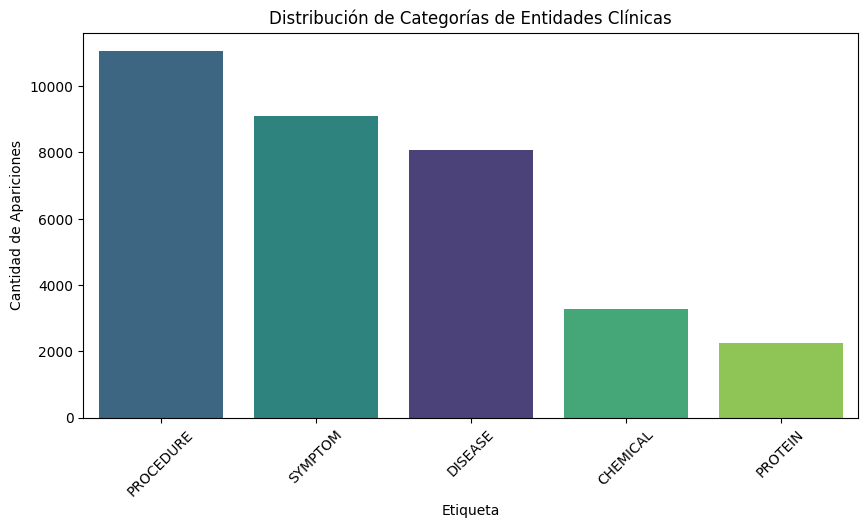


--- ESTADÍSTICAS DE PALABRAS POR ENTIDAD ---
count    33757.000000
mean         3.029268
std          3.035639
min          1.000000
25%          1.000000
50%          2.000000
75%          4.000000
max         44.000000
Name: entity_word_count, dtype: float64


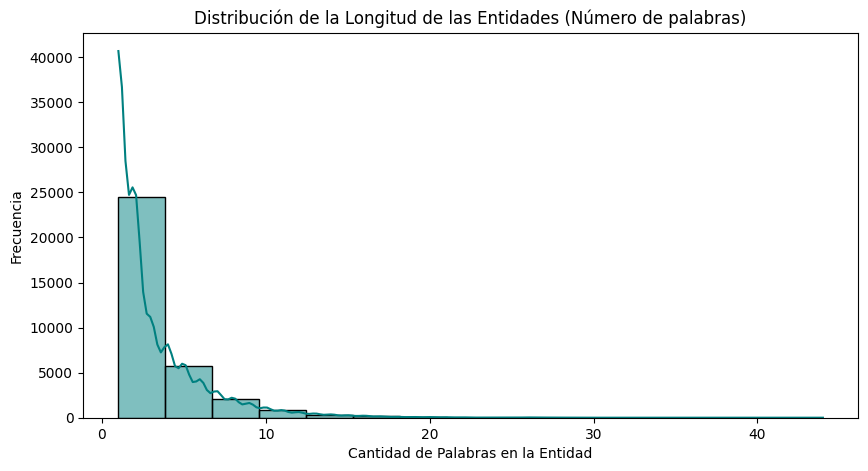


--- ESTADÍSTICAS DE ENTIDADES POR DOCUMENTO ---
count    750.000000
mean      45.009333
std       23.696032
min        9.000000
25%       28.000000
50%       40.500000
75%       57.000000
max      183.000000
dtype: float64


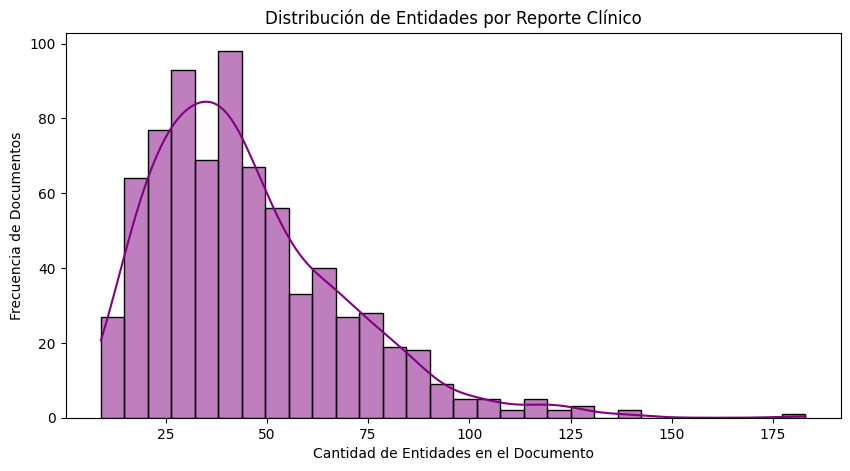

--- VERIFICACIÓN ESTRUCTURAL: TEST VS TRAIN ---
¿Las columnas son idénticas?: False
Columnas en Train: ['filename', 'ann_id', 'label', 'start_span', 'end_span', 'text', 'doc_id', 'entity_word_count']
Columnas en Test:  ['filename', 'ann_id', 'label', 'start_span', 'end_span', 'text', 'doc_id']

--- TIPOS DE DATOS EN TRAIN ---
filename             object
ann_id                int64
label                object
start_span            int64
end_span              int64
text                 object
doc_id               object
entity_word_count     int64
dtype: object

--- TIPOS DE DATOS EN TEST ---
filename      object
ann_id         int64
label         object
start_span     int64
end_span       int64
text          object
doc_id        object
dtype: object

Dimensiones Train (filas, columnas): (33757, 8)
Dimensiones Test (filas, columnas):  (11239, 7)


In [7]:


# 1. Inspección general
print("--- PRIMERAS 5 FILAS ---")
display(df_train.head())

print("\n--- VALORES NULOS ---")
print(df_train.isnull().sum())

# 2. Distribución de las clases / etiquetas de entidades
print("\n--- FRECUENCIA DE ETIQUETAS (LABELS) ---")
print(df_train['label'].value_counts())

plt.figure(figsize=(10, 5))
sns.countplot(
    data=df_train, 
    x='label', 
    hue='label',
    order=df_train['label'].value_counts().index,
    palette='viridis',
    legend=False
)
plt.title('Distribución de Categorías de Entidades Clínicas')
plt.xlabel('Etiqueta')
plt.ylabel('Cantidad de Apariciones')
plt.xticks(rotation=45)
plt.show()

# 3. Análisis del tamaño de las entidades (número de palabras por entidad)
df_train['entity_word_count'] = df_train['text'].apply(lambda x: len(str(x).split()))

print("\n--- ESTADÍSTICAS DE PALABRAS POR ENTIDAD ---")
print(df_train['entity_word_count'].describe())

plt.figure(figsize=(10, 5))
sns.histplot(df_train['entity_word_count'], bins=15, kde=True, color='teal')
plt.title('Distribución de la Longitud de las Entidades (Número de palabras)')
plt.xlabel('Cantidad de Palabras en la Entidad')
plt.ylabel('Frecuencia')
plt.show()

# 4. Análisis de densidad: ¿Cuántas entidades aparecen por cada documento clínico?
entities_per_file = df_train.groupby('filename').size()

print("\n--- ESTADÍSTICAS DE ENTIDADES POR DOCUMENTO ---")
print(entities_per_file.describe())

plt.figure(figsize=(10, 5))
sns.histplot(entities_per_file, bins=30, kde=True, color='purple')
plt.title('Distribución de Entidades por Reporte Clínico')
plt.xlabel('Cantidad de Entidades en el Documento')
plt.ylabel('Frecuencia de Documentos')
plt.show()




# Verificación estructural superficial
print("--- VERIFICACIÓN ESTRUCTURAL: TEST VS TRAIN ---")

# 1. Comparar columnas
columns_match = list(df_train.columns) == list(df_test.columns)
print(f"¿Las columnas son idénticas?: {columns_match}")
print(f"Columnas en Train: {df_train.columns.tolist()}")
print(f"Columnas en Test:  {df_test.columns.tolist()}")

# 2. Comparar tipos de datos (dtypes)
print("\n--- TIPOS DE DATOS EN TRAIN ---")
print(df_train.dtypes)

print("\n--- TIPOS DE DATOS EN TEST ---")
print(df_test.dtypes)

# 3. Verificación de dimensiones
print(f"\nDimensiones Train (filas, columnas): {df_train.shape}")
print(f"Dimensiones Test (filas, columnas):  {df_test.shape}")

- Distribución de Clases: encontramos un total de 33,757 entidades clínicas distribuidas en cinco categorías principales. PROCEDURE encabeza con 11,065 apariciones, seguida por SYMPTOM (9,091) y DISEASE (8,065). Las clases minoritarias corresponden a CHEMICAL (3,283) y PROTEIN (2,253). No encontramos valores nulos en ninguna columna, lo que valida la integridad de los datos descargados.

- La distribución de entidades presenta desbalance: PROCEDURE concentra el 32,78 % de las anotaciones, mientras PROTEIN representa solo el 6,68 %. Este desbalance puede favorecer el aprendizaje de las clases mayoritarias y reducir el recall de las minoritarias. Para mitigarlo se utilizarán pesos de clase en la función de pérdida y se reportarán métricas independientes por categoría.

- Longitud de las Entidades: observamos que la gran mayoría de las entidades médicas se concentran entre 1 y 3 palabras (con una media de 3.03 tokens por entidad). Sin embargo, existen casos complejos que alcanzan hasta 44 palabras. Esta variabilidad justifica nuestro uso de una red LSTM, ya que su arquitectura recurrente nos permite retener información de secuencias largas y capturar nombres clínicos compuestos extensos sin pérdida crítica de contexto.

- Densidad de Información por Documento: observamos un promedio de 45 entidades clínicas por cada reporte, con documentos que alcanzan un máximo de 183 menciones en un total de 750 archivos analizados. Esto confirma una alta densidad informativa por historia clínica, por lo que necesitamos que nuestro DataLoader gestione secuencias de texto amplias durante la vectorización con spaCy.

- Con la verificación estructural comprobamos que ambos conjuntos de datos, entrenamiento y prueba, son totalmente compatibles:

  Las columnas de entrenamiento y prueba son idénticas (filename, ann_id, label, start_span, end_span, text).

  Los tipos de datos coinciden de manera exacta en todos los campos, lo que nos garantiza que el pipeline de transformación que aplicamos al conjunto de entrenamiento funciona de forma idéntica en el conjunto de prueba sin errores de tipo.

  La proporción de los datos es coherente para un split de validación/prueba estándar en machine learning: contamos con 33,757 registros de entrenamiento y 11,239 registros de prueba.

  Con esta validación completada y libre de fugas de datos (data leakage), dejamos preparado el terreno para estructurar la transformación de los textos clínicos a nivel de documento y token.

### PASO 05 — Partición fija por documento

Seleccionamos los documentos oficiales de entrenamiento y separamos la validación usando `split_seed=42`. Hacemos la división por documento completo, nunca por filas de entidades, para evitar que texto del mismo caso aparezca en entrenamiento y validación. Guardamos una huella SHA-256 de la partición; las seis ejecuciones posteriores deben compartir exactamente esta huella. En la configuración completa usamos 600 documentos de train y 150 de validación.

In [8]:
# PASO 05 — Partición única compartida por ambas variantes (sin test)
# Mezclamos aleatoriamente los documentos de train oficiales (con split_seed fijo) y
# tomamos una fracción de ellos (CFG['fraction']); del resultado, el primer tramo
# (validation_fraction, 20% por defecto) queda como validación y el resto como
# entrenamiento. La partición es por documento completo (no por fila de entidad),
# y la reutilizan tanto la variante con_pos como sin_pos.
rng = np.random.default_rng(CFG['split_seed'])
order = rng.permutation(official_train_ids).tolist()
n_sample = min(len(order), max(5, math.ceil(len(order) * CFG['fraction'])))
selected = order[:n_sample]
n_val = max(1, round(n_sample * CFG['validation_fraction']))
val_ids, train_ids = sorted(selected[:n_val]), sorted(selected[n_val:])
assert train_ids and val_ids
assert not set(train_ids) & set(val_ids)
# Confirmamos que ningún texto de validación sea idéntico a uno de entrenamiento
# (evita fuga de datos aunque los identificadores de documento no coincidan).
assert not {fingerprint(texts[k]) for k in train_ids} & {fingerprint(texts[k]) for k in val_ids}
split_payload = {'train': train_ids, 'validation': val_ids, 'official_test': official_test_ids}
# Huella (hash) de la partición completa: nos permite comprobar, en los pasos
# siguientes, que las seis ejecuciones del PASO 10 usaron exactamente los mismos documentos.
split_sha256 = hashlib.sha256(json.dumps(split_payload, sort_keys=True).encode()).hexdigest()
REPORT['split'] = {'sample_documents': n_sample, 'train_documents': len(train_ids),
                   'validation_documents': len(val_ids), 'test_used_for_training': False,
                   'split_seed': CFG['split_seed'], 'sha256': split_sha256}
(RUN / 'split.json').write_text(json.dumps({**split_payload, 'split_seed': CFG['split_seed'], 'sha256': split_sha256}, indent=2), encoding='utf-8')
print('PASO 05 — MUESTRA:', json.dumps(REPORT['split'], indent=2))
print('Anotaciones por categoría en la muestra:')
print(df_train[df_train.doc_id.isin(selected)].label.value_counts().to_string())
print('PASO 05 OK. Ambas variantes usarán estos mismos documentos; todavía no comenzó a entrenar.')

PASO 05 — MUESTRA: {
  "sample_documents": 750,
  "train_documents": 600,
  "validation_documents": 150,
  "test_used_for_training": false,
  "split_seed": 42,
  "sha256": "ab06b4e8dd54e120c2fed93f276f1944a6e67c5227281778c38add2eea4dc497"
}
Anotaciones por categoría en la muestra:
label
PROCEDURE    11065
SYMPTOM       9091
DISEASE       8065
CHEMICAL      3283
PROTEIN       2253
PASO 05 OK. Ambas variantes usarán estos mismos documentos; todavía no comenzó a entrenar.


### PASO 06 — Tokenización, alineación y bloques BIO

Procesamos los documentos completos con spaCy en lotes, obtenemos tokens y POS, y alineamos los offsets de las anotaciones con esos tokens. Convertimos las entidades planas retenidas a etiquetas `B-*` e `I-*`; excluimos y contabilizamos las anotaciones anidadas, solapadas o no alineables. Dividimos cada documento en bloques sin truncar silenciosamente el texto y enmascaramos los tokens que no deben tratarse como negativos. Guardamos las características en caché para no repetir el preprocesamiento en ejecuciones posteriores.

In [9]:
# PASO 06 — POS por lotes, alineación BIO y bloques sin truncamiento
t0 = time.perf_counter()
nlp = spacy.load(CFG['spacy_model'], disable=['parser', 'ner', 'lemmatizer'])
REPORT['versions']['spacy_model'] = nlp.meta['version']
print('spaCy activo:', nlp.pipe_names, flush=True)

def make_examples(ids, annotations, split_name):
    """Convierte los documentos `ids` en ejemplos de entrenamiento con tokens, POS y
    etiquetas BIO, listos para el modelo. Por cada documento:

    1. Tokeniza con spaCy (ya corrido en lote) y obtiene el POS de cada token.
    2. Alinea cada anotación (offsets de caracter en el texto) con los tokens usando
       `char_span`; si una anotación no cae exactamente sobre límites de token, la
       descarta y la cuenta como 'unaligned'.
    3. Si dos anotaciones alineadas se solapan en tokens, conserva la más larga (y, en
       empate, la de inicio más temprano) y descarta el resto como 'overlap_excluded'.
       Esto es lo que hace el esquema "BIO plano": no admite entidades anidadas.
    4. Etiqueta los tokens de cada entidad conservada como `B-<label>` (primer token)
       e `I-<label>` (resto). Los tokens que pertenecían a una anotación descartada
       (no alineada o solapada) se marcan con `IGNORE`, para no castigarlos como
       negativos verdaderos ('O') durante el entrenamiento; los demás tokens sí quedan
       como 'O'.
    5. Divide cada documento en bloques de como máximo `CFG['max_tokens']` tokens, sin
       cortar el texto: si el corte natural cae en medio de una entidad (un token 'I-'
       justo después del límite), retrocede el corte hasta el inicio de esa entidad
       (o, si no puede, avanza hasta que la entidad termine) para no partirla.

    El resultado se guarda en caché en disco (la clave del archivo depende de los
    documentos, las anotaciones, la versión de spaCy y la política de alineación), de
    forma que si se vuelve a ejecutar esta PASO con los mismos datos no se repite este
    preprocesamiento, que es el más lento del cuaderno.

    Devuelve la lista de ejemplos (bloques) y un diccionario de estadísticas
    (documentos procesados, anotaciones retenidas/duplicadas/excluidas, tokens, etc.).
    """
    # Caché de features, ligada a textos, anotaciones, versión y política de alineación.
    subset = annotations[annotations.doc_id.isin(ids)]
    key = hashlib.sha256(json.dumps({'ids': ids, 'max_tokens': CFG['max_tokens'],
        'model': CFG['spacy_model'], 'version': nlp.meta['version'], 'spacy': spacy.__version__,
        'policy': 'flat-longest-strict-mask-v1',
        'texts': [fingerprint(texts[k]) for k in ids],
        'annotations': subset[['doc_id','start_span','end_span','label']].to_json()}
        , sort_keys=True).encode()).hexdigest()
    cache_file = CACHE / f'features_{key}.json'
    start = time.perf_counter()
    if cache_file.exists():
        payload = json.loads(cache_file.read_text(encoding='utf-8'))
        payload['stats']['cache_hit'] = True
        payload['stats']['seconds_this_run'] = time.perf_counter() - start
        (RUN / f'alignment_{split_name}.json').write_text(json.dumps(payload['stats'], indent=2), encoding='utf-8')
        return payload['examples'], payload['stats']
    groups = {k: g for k, g in subset.groupby('doc_id')}
    examples, excluded = [], []
    stats = Counter(documents=len(ids), annotations=0, duplicates=0, unaligned=0,
                    overlap_excluded=0, retained=0, tokens=0, ignored_tokens=0)
    retained_by_label = Counter()
    for key_id, doc in tqdm(zip(ids, nlp.pipe((texts[k] for k in ids), batch_size=16, n_process=1)),
                            total=len(ids), desc=f'POS y BIO {split_name}'):
        assert len(doc) > 0
        gold = [0] * len(doc)
        candidates, ignored_spans, seen = [], [], set()
        for row in groups[key_id].itertuples(index=False):
            a, b, label = int(row.start_span), int(row.end_span), row.label
            stats['annotations'] += 1
            identity = (a, b, label)
            if identity in seen:
                stats['duplicates'] += 1
                continue
            seen.add(identity)
            span = doc.char_span(a, b, alignment_mode='strict')
            if span is None:
                stats['unaligned'] += 1
                ignored_spans.append((a, b))
                excluded.append({'doc_id': key_id, 'start': a, 'end': b, 'label': label, 'reason': 'unaligned'})
            else:
                candidates.append((a, b, label, span.start, span.end))
        # Resolvemos solapes eligiendo primero las entidades más largas (y, en empate,
        # las que empiezan antes); una vez asignados sus tokens en `gold`, cualquier
        # candidata que se solape con una ya asignada se descarta.
        for a, b, label, i, j in sorted(candidates, key=lambda x: (-(x[1]-x[0]), x[0], x[2])):
            if any(gold[k] != 0 for k in range(i, j)):
                stats['overlap_excluded'] += 1
                ignored_spans.append((a, b))
                excluded.append({'doc_id': key_id, 'start': a, 'end': b, 'label': label, 'reason': 'overlap'})
                continue
            gold[i] = tag_to_ix[f'B-{label}']
            gold[i+1:j] = [tag_to_ix[f'I-{label}']] * (j-i-1)
            stats['retained'] += 1
            retained_by_label[label] += 1
        # Los tokens de anotaciones descartadas no son negativos O, salvo que otra
        # entidad retenida ya les haya asignado una etiqueta válida.
        for token in doc:
            if gold[token.i] == 0 and any(token.idx < b and token.idx + len(token) > a for a, b in ignored_spans):
                gold[token.i] = IGNORE
        words = [token.text for token in doc]
        pos = [pos_to_ix.get(token.pos_, 1) for token in doc]
        stats['tokens'] += len(doc)
        stats['ignored_tokens'] += gold.count(IGNORE)
        start_token = 0
        while start_token < len(doc):
            end = min(start_token + CFG['max_tokens'], len(doc))
            # Si el siguiente token es I-, el corte cae dentro de una entidad.
            if end < len(doc) and gold[end] >= 0 and TAGS[gold[end]].startswith('I-'):
                # Primero intentamos retroceder el corte hasta el inicio de esa entidad
                # (para no partirla); si el bloque quedaría vacío, en su lugar avanzamos
                # el corte hasta que la entidad termine.
                cut = end
                while cut > start_token and gold[cut] >= 0 and TAGS[gold[cut]].startswith('I-'):
                    cut -= 1
                if cut > start_token:
                    end = cut
                else:
                    while end < len(doc) and gold[end] >= 0 and TAGS[gold[end]].startswith('I-'):
                        end += 1
            assert end > start_token
            examples.append({'doc_id': key_id, 'start_token': start_token, 'tokens': words[start_token:end],
                             'pos': pos[start_token:end], 'labels': gold[start_token:end]})
            start_token = end
    stats = dict(stats)
    stats.update(retained_by_label=dict(retained_by_label), cache_hit=False,
                 sequences=len(examples), seconds_this_run=time.perf_counter() - start,
                 excluded_examples=excluded[:20])
    assert sum(len(e['tokens']) for e in examples) == stats['tokens'], 'Se perdieron tokens.'
    assert stats.get('retained', 0) > 0, 'No quedaron entidades. Comparte este error.'
    payload = {'examples': examples, 'stats': stats}
    cache_file.write_text(json.dumps(payload, ensure_ascii=False), encoding='utf-8')
    (RUN / f'alignment_{split_name}.json').write_text(json.dumps(stats, indent=2), encoding='utf-8')
    return examples, stats

train_examples, train_stats = make_examples(train_ids, df_train, 'train')
val_examples, val_stats = make_examples(val_ids, df_train, 'validation')
REPORT['alignment'] = {'train': train_stats, 'validation': val_stats}
REPORT['preprocessing_seconds'] = time.perf_counter() - t0
for name, stats in REPORT['alignment'].items():
    print(name, json.dumps({k:v for k,v in stats.items() if k != 'excluded_examples'}, indent=2))
print('PASO 06 OK. Detalle de exclusiones en alignment_*.json.')

spaCy activo: ['tok2vec', 'morphologizer', 'attribute_ruler']


POS y BIO train:   0%|          | 0/600 [00:00<?, ?it/s]

POS y BIO validation:   0%|          | 0/150 [00:00<?, ?it/s]

train {
  "documents": 600,
  "annotations": 26849,
  "duplicates": 0,
  "unaligned": 197,
  "overlap_excluded": 4251,
  "retained": 22401,
  "tokens": 242172,
  "ignored_tokens": 943,
  "retained_by_label": {
    "SYMPTOM": 6325,
    "DISEASE": 5866,
    "PROCEDURE": 7253,
    "PROTEIN": 1090,
    "CHEMICAL": 1867
  },
  "cache_hit": false,
  "sequences": 2204,
  "seconds_this_run": 10.424831805000053
}
validation {
  "documents": 150,
  "annotations": 6908,
  "duplicates": 0,
  "unaligned": 57,
  "overlap_excluded": 990,
  "retained": 5861,
  "tokens": 62994,
  "ignored_tokens": 277,
  "retained_by_label": {
    "PROCEDURE": 1906,
    "DISEASE": 1391,
    "SYMPTOM": 1682,
    "CHEMICAL": 577,
    "PROTEIN": 305
  },
  "cache_hit": false,
  "sequences": 562,
  "seconds_this_run": 2.5676922939999827
}
PASO 06 OK. Detalle de exclusiones en alignment_*.json.


### PASO 07 — Vocabulario, lotes y función de pérdida

Construimos el vocabulario de palabras usando solo los bloques de entrenamiento; las palabras nuevas de validación pasan a `<UNK>`. Definimos el padding dinámico, los `DataLoader` y los pesos moderados por clase. `O` es una etiqueta válida que la red aprende; solo usamos `IGNORE=-100` para el padding y las posiciones no evaluables. Con la función `loss_parts` impedimos continuar con un lote sin etiquetas válidas y evitamos ocultar errores mediante pérdidas `NaN`.

In [10]:
# PASO 07 — Vocabulario solo de train; padding dinámico y pesos moderados
counts = Counter(token for e in train_examples for token in e['tokens'])
word_to_ix = {'<PAD>': 0, '<UNK>': 1}
for token in sorted(counts, key=lambda w: (-counts[w], w)):
    if token not in word_to_ix:
        word_to_ix[token] = len(word_to_ix)

class ClinicalDataset(Dataset):
    """Dataset de PyTorch que envuelve los bloques (ejemplos) generados en el PASO 06.
    Convierte cada bloque a tensores de índices: palabras (según `word_to_ix`, con
    `<UNK>`=1 para palabras no vistas en entrenamiento), POS y etiquetas BIO."""
    def __init__(self, examples): self.examples = examples
    def __len__(self): return len(self.examples)
    def __getitem__(self, idx):
        e = self.examples[idx]
        return (torch.tensor([word_to_ix.get(w, 1) for w in e['tokens']], dtype=torch.long),
                torch.tensor(e['pos'], dtype=torch.long), torch.tensor(e['labels'], dtype=torch.long))

def collate(batch):
    """Función de collate del DataLoader: junta una lista de ejemplos de distinta
    longitud en un solo lote, aplicando padding dinámico (cada lote se rellena solo
    hasta la longitud de su secuencia más larga, no hasta `max_tokens`). Además de las
    secuencias rellenadas, devuelve `lengths` con el largo real de cada secuencia, que
    el encoder usa para construir la máscara de atención."""
    words, pos, labels = zip(*batch)
    return {'input_ids': pad_sequence(words, batch_first=True, padding_value=0),
            'pos_ids': pad_sequence(pos, batch_first=True, padding_value=0),
            'labels': pad_sequence(labels, batch_first=True, padding_value=IGNORE),
            'lengths': torch.tensor([len(w) for w in words], dtype=torch.long)}

train_dataset, val_dataset = ClinicalDataset(train_examples), ClinicalDataset(val_examples)
generator = torch.Generator().manual_seed(CFG['training_seeds'][0])
train_loader = DataLoader(train_dataset, batch_size=CFG['batch_size'], shuffle=True,
                          collate_fn=collate, num_workers=0, generator=generator, pin_memory=(device.type == 'cuda'))
val_loader = DataLoader(val_dataset, batch_size=CFG['batch_size'], shuffle=False,
                        collate_fn=collate, num_workers=0, pin_memory=(device.type == 'cuda'))
label_counts = Counter(y for e in train_examples for y in e['labels'] if y != IGNORE)
assert label_counts[0] > 0 and sum(v for k,v in label_counts.items() if k > 0) > 0
weights = torch.ones(len(TAGS))
if CFG['class_weights']:
    # Pesos inversamente proporcionales a la frecuencia de cada etiqueta (suavizados con
    # raíz cuadrada y acotados entre 0.25 y 5) para que la clase mayoritaria 'O' no
    # domine la pérdida frente a las etiquetas de entidad, mucho más escasas.
    freq = torch.tensor([label_counts[i] for i in range(len(TAGS))], dtype=torch.float)
    present = freq > 0
    weights[present] = (freq[present].sum() / (present.sum() * freq[present])).sqrt().clamp(0.25, 5.0)
weights = weights.to(device)
criterion = nn.CrossEntropyLoss(weight=weights, ignore_index=IGNORE, reduction='none').to(device)

def loss_parts(logits, labels):
    """Calcula la pérdida de entropía cruzada ponderada por clase, ignorando las
    posiciones marcadas con `IGNORE` (padding y anotaciones descartadas). En vez de
    devolver directamente el promedio, devuelve el numerador (suma de pérdidas) y el
    denominador (suma de pesos) por separado, para poder acumularlos correctamente a
    través de varios lotes de distinto tamaño (por ejemplo, en el reporte de la época).
    Lanza un error si el lote no tiene ninguna etiqueta válida, en vez de omitirlo en
    silencio, para no ocultar un problema de alineación de datos."""
    valid = labels != IGNORE
    if not valid.any():
        raise RuntimeError('Lote sin etiquetas válidas: revisar alineación, no omitirlo silenciosamente.')
    losses = criterion(logits.reshape(-1, len(TAGS)), labels.reshape(-1))
    numerator = losses.sum()
    denominator = weights[labels[valid]].sum()
    return numerator / denominator, numerator, denominator

val_tokens = [w for e in val_examples for w in e['tokens']]
REPORT['vocabulary'] = {'size': len(word_to_ix),
    'validation_unknown_fraction': sum(w not in word_to_ix for w in val_tokens) / len(val_tokens),
    'train_tag_counts': {TAGS[k]: v for k,v in sorted(label_counts.items())},
    'missing_train_tags': [TAGS[i] for i in range(len(TAGS)) if label_counts[i] == 0]}
(RUN / 'vocabulary.json').write_text(json.dumps({'words': word_to_ix, 'pos': pos_to_ix,
    'tags': tag_to_ix, 'ignore_index': IGNORE}, ensure_ascii=False), encoding='utf-8')
print('PASO 07 OK:', json.dumps(REPORT['vocabulary'], indent=2))
if REPORT['vocabulary']['missing_train_tags']:
    print('AVISO: faltan etiquetas en esta muestra; la prueba no permite valorar esas etiquetas.')

PASO 07 OK: {
  "size": 20295,
  "validation_unknown_fraction": 0.054703622567228626,
  "train_tag_counts": {
    "O": 167635,
    "B-CHEMICAL": 1867,
    "I-CHEMICAL": 251,
    "B-DISEASE": 5866,
    "I-DISEASE": 13097,
    "B-PROCEDURE": 7253,
    "I-PROCEDURE": 16851,
    "B-PROTEIN": 1090,
    "I-PROTEIN": 336,
    "B-SYMPTOM": 6325,
    "I-SYMPTOM": 20658
  },
  "missing_train_tags": []
}


### PASO 08 — Encoder desde cero y métricas

La entrada tiene forma `[B, L]`. Los embeddings de palabra, concatenados opcionalmente con POS, se proyectan a `d_model`. Sumamos posiciones sinusoidales y aplicamos los bloques:

`x → LayerNorm(x + Dropout(MultiHeadAttention(x))) → LayerNorm(x + Dropout(FFN(x)))`

Cada cabeza calcula `softmax(QKᵀ / sqrt(d_k))V`. En nuestra máscara `True` significa token real; las claves de padding reciben `-inf` antes de softmax. No hay máscara causal: se puede atender a todo el bloque. Las posiciones de padding se anulan al finalizar cada bloque y se ignoran en la pérdida. La salida es `[B, L, 11]` de logits, sin aplicar softmax antes de entropía cruzada.

Calculamos posiciones sinusoidales para la longitud real del lote: así admitimos padding adicional y bloques excepcionales mayores de 128 tokens cuando una entidad gold no se puede dividir. No se usan módulos de encoder empaquetados.

In [11]:
# PASO 08 — Transformer encoder desde cero; clasificación por token
class SinusoidPE(nn.Module):
    """Misma fórmula de clase, calculada en el dispositivo y longitud del lote."""
    def __init__(self, d_model):
        super().__init__()
        frequencies = torch.exp(torch.arange(0, d_model, 2, dtype=torch.float32)
                                * (-math.log(10000.0) / d_model))
        self.register_buffer('frequencies', frequencies)
        self.d_model = d_model

    def forward(self, x):
        positions = torch.arange(x.shape[1], device=x.device, dtype=torch.float32)
        angles = positions[:, None] * self.frequencies[None, :]
        pe = torch.zeros(x.shape[1], self.d_model, device=x.device, dtype=torch.float32)
        pe[:, 0::2] = angles.sin()
        pe[:, 1::2] = angles[:, :self.d_model // 2].cos()
        return x + pe.to(x.dtype).unsqueeze(0)


class MultiHeadAttention(nn.Module):
    """Q/K/V y combinación de cabezas explícitas; máscara [B, L] de tokens reales."""
    def __init__(self, embed_size, num_heads):
        super().__init__()
        assert num_heads > 0 and embed_size % num_heads == 0
        self.num_heads = num_heads
        self.head_dim = embed_size // num_heads
        self.query = nn.Linear(embed_size, embed_size)
        self.key = nn.Linear(embed_size, embed_size)
        self.value = nn.Linear(embed_size, embed_size)
        self.combine_heads = nn.Linear(embed_size, embed_size)

    def forward(self, x, valid_mask, return_attention=False):
        batch, length, width = x.shape
        def heads(projection):
            return projection(x).reshape(batch, length, self.num_heads, self.head_dim).transpose(1, 2)
        q, k, v = heads(self.query), heads(self.key), heads(self.value)
        scores = (q @ k.transpose(-2, -1)) / math.sqrt(self.head_dim)
        scores = scores.masked_fill(~valid_mask[:, None, None, :], float('-inf'))
        attention = torch.softmax(scores, dim=-1)
        context = (attention @ v).transpose(1, 2).contiguous().reshape(batch, length, width)
        output = self.combine_heads(context)
        return (output, attention) if return_attention else output


class TransformerBlock(nn.Module):
    def __init__(self, d_model, num_heads, ff_dim, dropout):
        super().__init__()
        self.attention = MultiHeadAttention(d_model, num_heads)
        self.ffn = nn.Sequential(nn.Linear(d_model, ff_dim), nn.ReLU(),
                                 nn.Dropout(dropout), nn.Linear(ff_dim, d_model))
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)

    def forward(self, x, valid_mask):
        x = self.norm1(x + self.dropout1(self.attention(x, valid_mask)))
        x = self.norm2(x + self.dropout2(self.ffn(x)))
        return x.masked_fill(~valid_mask.unsqueeze(-1), 0.0)


class ClinicalTransformer(nn.Module):
    def __init__(self, use_pos=True):
        super().__init__()
        self.use_pos = bool(use_pos)
        self.word_embedding = nn.Embedding(len(word_to_ix), CFG['embedding_dim'], padding_idx=0)
        self.pos_embedding = nn.Embedding(len(POS), CFG['pos_dim'], padding_idx=0) if use_pos else None
        input_dim = CFG['embedding_dim'] + (CFG['pos_dim'] if use_pos else 0)
        self.input_projection = nn.Linear(input_dim, CFG['d_model'])
        self.position = SinusoidPE(CFG['d_model'])
        self.dropout = nn.Dropout(CFG['dropout'])
        self.blocks = nn.ModuleList([TransformerBlock(CFG['d_model'], CFG['num_heads'],
                                    CFG['ff_dim'], CFG['dropout']) for _ in range(CFG['layers'])])
        self.fc = nn.Linear(CFG['d_model'], len(TAGS))

    def forward(self, input_ids, pos_ids, lengths):
        # Longitudes > 0 garantizadas por ClinicalDataset/collate; no se admiten textos vacíos.
        valid_mask = torch.arange(input_ids.shape[1], device=input_ids.device)[None, :] < lengths[:, None]
        x = self.word_embedding(input_ids)
        if self.use_pos:
            x = torch.cat([x, self.pos_embedding(pos_ids)], dim=-1)
        x = self.dropout(self.position(self.input_projection(x)))
        x = x.masked_fill(~valid_mask.unsqueeze(-1), 0.0)
        for block in self.blocks:
            x = block(x, valid_mask)
        return self.fc(self.dropout(x))

def entity_spans(tag_ids):
    """Agrupa una secuencia de índices de etiqueta BIO en entidades completas
    `(inicio, fin, categoría)`. Recorre los índices y va extendiendo la entidad activa
    mientras encuentra `I-<misma categoría>`; en cualquier otro caso cierra la entidad
    activa (si había una) y, si el tag es `B-` o `I-`, abre una nueva.

    Una `I-` que aparece sin una entidad activa de la misma categoría es una transición
    BIO ilegal (no debería pasar en las etiquetas reales, pero sí puede pasar en las
    predicciones del modelo); en ese caso, en vez de descartarla, la tratamos igual como
    inicio de una nueva entidad (reparación determinista) y contamos cuántas veces
    ocurrió esto en `invalid`.

    Devuelve el conjunto de entidades encontradas y el número de transiciones
    inválidas reparadas."""
    # Una I- ilegal inicia entidad (reparación determinista); se cuenta por separado.
    result, active, begin, invalid = set(), None, None, 0
    for i, idx in enumerate(list(tag_ids) + [0]):
        tag = TAGS[idx] if idx >= 0 else 'O'
        prefix, label = tag.split('-', 1) if tag != 'O' else ('O', None)
        continuing = prefix == 'I' and label == active
        if active is not None and not continuing:
            result.add((begin, i, active)); active = None
        if prefix in ('B', 'I') and not continuing:
            invalid += int(prefix == 'I')
            begin, active = i, label
    return result, invalid

def scores_from_counts(tp, predicted, gold):
    """Calcula precisión, recall y F1 a partir de conteos agregados: verdaderos
    positivos (`tp`), total de entidades predichas (`predicted`) y total de entidades
    reales (`gold`)."""
    precision = tp / predicted if predicted else 0.0
    recall = tp / gold if gold else 0.0
    return {'precision': precision, 'recall': recall,
            'f1': 2*precision*recall/(precision+recall) if precision+recall else 0.0,
            'support': gold, 'predicted': predicted}

@torch.no_grad()
def evaluate(model, loader):
    """Evalúa el modelo sobre un DataLoader completo, en modo inferencia.
    Por cada lote: acumula la pérdida (para reportarla) y la exactitud por token, y
    reconstruye las entidades predichas y reales con `entity_spans` para comparar
    coincidencia EXACTA de límites y categoría (no basta con acertar tokens sueltos).
    Acumula verdaderos positivos/predichos/reales por categoría (`per_label`) y en
    total (`micro`), y cuenta las transiciones BIO inválidas que tuvo que reparar
    `entity_spans` en las predicciones (en el gold no debería haber ninguna, por eso
    se afirma con `assert`).

    Devuelve un diccionario con la pérdida, las métricas micro y por categoría, la
    exactitud por token y el conteo de transiciones inválidas."""
    model.eval()
    totals = {label: Counter() for label in LABELS}
    numerator = denominator = correct = tokens = invalid = 0
    for batch in loader:
        batch = move_batch(batch)
        logits = model(batch['input_ids'], batch['pos_ids'], batch['lengths'])
        _, num, den = loss_parts(logits, batch['labels'])
        numerator += num.item(); denominator += den.item()
        pred = logits.argmax(-1)
        mask = batch['labels'] != IGNORE
        correct += ((pred == batch['labels']) & mask).sum().item(); tokens += mask.sum().item()
        for p, g, length in zip(pred.tolist(), batch['labels'].tolist(), batch['lengths'].tolist()):
            g = g[:length]; p = p[:length]
            # Mantener posiciones; no unir entidades a través de huecos ignorados.
            p = [x if y != IGNORE else 0 for x, y in zip(p, g)]
            g = [y if y != IGNORE else 0 for y in g]
            ps, errors = entity_spans(p); gs, gold_errors = entity_spans(g)
            assert gold_errors == 0, 'BIO gold inválido.'
            invalid += errors
            for label in LABELS:
                totals[label].update(tp=sum(x[2] == label for x in ps & gs),
                    predicted=sum(x[2] == label for x in ps), gold=sum(x[2] == label for x in gs))
    per_label = {k: scores_from_counts(v['tp'], v['predicted'], v['gold']) for k,v in totals.items()}
    micro = scores_from_counts(sum(v['tp'] for v in totals.values()),
                               sum(v['predicted'] for v in totals.values()), sum(v['gold'] for v in totals.values()))
    return {'loss': numerator / denominator, 'micro': micro, 'per_label': per_label,
            'token_accuracy': correct / tokens, 'invalid_bio_transitions': invalid}

print('PASO 08 OK. Modelo definido; aún no se ha entrenado.')

PASO 08 OK. Modelo definido; aún no se ha entrenado.


### PASO 09 — Prueba técnica de las dos variantes

Antes de invertir tiempo en los seis entrenamientos, creamos modelos temporales con y sin POS. Comprobamos que la pérdida baje al repetir un lote, que existan gradientes finitos, que el padding no cambie las salidas y que funcionen lotes pequeños o con longitudes distintas. También registramos los dispositivos usados: `cuda:0` y `cuda:1`. Si esta PASO falla, no continúes con el PASO 10; comparte el bloque `ERROR_PARA_COMPARTIR`.

In [12]:
# PASO 09 — PRUEBA TÉCNICA: ambas GPU, gradientes, padding y lote desigual
# Modelo temporal: sus pesos NO pasan al entrenamiento de el PASO 10.
def run_smoke_test(use_pos):
    """Prueba técnica rápida (no es el entrenamiento real) que valida, antes de
    invertir tiempo en los seis entrenamientos de el PASO 10:

    - Que la pérdida efectivamente baja al repetir 20 veces el mismo lote pequeño
      (si no bajara, algo estaría mal en el modelo, la pérdida o el optimizador).
    - Que los gradientes son finitos y no nulos (no hay NaN/Inf ni un modelo que no
      aprende nada).
    - Que ambas GPU configuradas participan realmente del cómputo, verificado con un
      hook que registra en qué dispositivo se ejecutó la capa final (`fc`).
    - Que el resultado no cambia si se agrega padding extra a la derecha de la
      entrada (invariancia al padding: importante porque distintos lotes tienen
      distinto largo máximo).
    - En la variante sin POS, que cambiar `pos_ids` no afecta la salida, confirmando
      que en verdad se ignoran (y no que `use_pos=False` sea solo una bandera cosmética).
    - Que el modelo produce el mismo resultado con lotes más pequeños o de tamaño
      desigual (como puede ocurrir con el último lote de una época).

    Los pesos de este modelo temporal se descartan al terminar la prueba; nunca pasan
    al entrenamiento real de el PASO 10."""
    import threading
    synchronize_devices()
    t0 = time.perf_counter()
    probe_batch = move_batch(collate([train_dataset[i] for i in range(min(4, len(train_dataset)))]))
    torch.manual_seed(CFG['training_seeds'][0])
    if device_ids:
        torch.cuda.manual_seed_all(CFG['training_seeds'][0])
    base = ClinicalTransformer(use_pos=use_pos)
    # Desactivar dropout para comprobar aprendizaje e invariancia deterministas.
    for module in base.modules():
        if isinstance(module, nn.Dropout): module.p = 0.0
    observed, lock = set(), threading.Lock()
    def record_device(module, inputs, output):
        """Hook de forward que registra en qué dispositivo (por ejemplo 'cuda:0' o
        'cuda:1') se ejecutó la capa, para comprobar que DataParallel efectivamente
        repartió el lote entre todas las GPU configuradas."""
        with lock:
            observed.add(str(output.device))
    handle = base.fc.register_forward_hook(record_device)
    probe = prepare_model(base)
    probe.train()
    probe_optimizer = torch.optim.Adam(probe.parameters(), lr=CFG['learning_rate'])
    losses = []
    for step in range(20):
        probe_optimizer.zero_grad(set_to_none=True)
        logits = probe(probe_batch['input_ids'], probe_batch['pos_ids'], probe_batch['lengths'])
        loss, _, _ = loss_parts(logits, probe_batch['labels'])
        assert torch.isfinite(loss), 'Pérdida no finita en prueba técnica.'
        loss.backward()
        norm = torch.nn.utils.clip_grad_norm_(probe.parameters(), 1.0, error_if_nonfinite=True)
        assert norm > 0, 'Gradiente nulo: revisar etiquetas.'
        probe_optimizer.step()
        losses.append(loss.item())
    handle.remove()
    expected = {f'cuda:{i}' for i in device_ids} if device_ids else {'cpu'}
    assert observed == expected, f'GPU ejecutadas: {observed}; esperadas: {expected}.'
    assert min(losses[-5:]) < losses[0], 'La pérdida no bajó al repetir el lote.'
    probe.eval()
    with torch.no_grad():
        original = probe(probe_batch['input_ids'], probe_batch['pos_ids'], probe_batch['lengths'])
        valid = torch.arange(probe_batch['input_ids'].shape[1], device=device)[None, :] < probe_batch['lengths'][:, None]
        attn_module = unwrap(probe).blocks[0].attention
        sample_x = torch.randn(valid.shape[0], valid.shape[1], CFG['d_model'], device=device)
        _, attn_weights = attn_module(sample_x, valid, return_attention=True)
        torch.testing.assert_close(attn_weights.sum(-1), torch.ones_like(attn_weights.sum(-1)))
        masked_values = attn_weights.masked_select((~valid)[:, None, None, :].expand_as(attn_weights))
        assert (masked_values == 0).all(), 'El padding recibió atención.'
        # Oráculo independiente de PyTorch para la ecuación de atención, sin dropout.
        q, k, v = [projection(sample_x).reshape(valid.shape[0], valid.shape[1],
                   CFG['num_heads'], -1).transpose(1, 2)
                   for projection in (attn_module.query, attn_module.key, attn_module.value)]
        reference = torch.nn.functional.scaled_dot_product_attention(
            q, k, v, attn_mask=valid[:, None, None, :], dropout_p=0.0)
        reference = attn_module.combine_heads(reference.transpose(1, 2).contiguous().reshape_as(sample_x))
        torch.testing.assert_close(attn_module(sample_x, valid), reference, atol=1e-5, rtol=1e-4)
        assert (attn_weights[0, :, 0, :int(probe_batch['lengths'][0])] > 0).all(), 'Atención inesperadamente causal.'
        if not use_pos:
            assert unwrap(probe).pos_embedding is None
            changed_pos = (probe_batch['pos_ids'] + 1) % len(POS)
            without_pos = probe(probe_batch['input_ids'], changed_pos, probe_batch['lengths'])
            torch.testing.assert_close(original, without_pos, atol=1e-5, rtol=1e-4)
        padded = probe(torch.nn.functional.pad(probe_batch['input_ids'], (0, 7)),
                       torch.nn.functional.pad(probe_batch['pos_ids'], (0, 7)), probe_batch['lengths'])
        torch.testing.assert_close(original, padded[:, :original.shape[1]], atol=1e-5, rtol=1e-4)
        # Simular longitudes máximas diferentes por réplica y un último lote pequeño.
        for size in (1, 3, 4):
            size = min(size, len(probe_batch['lengths']))
            words, pos = probe_batch['input_ids'][:size], probe_batch['pos_ids'][:size]
            lengths = torch.minimum(probe_batch['lengths'][:size],
                                    torch.arange(1, size+1, device=device))
            parallel = probe(words, pos, lengths)
            single = unwrap(probe)(words, pos, lengths)
            assert parallel.shape == (size, words.shape[1], len(TAGS))
            torch.testing.assert_close(parallel, single, atol=1e-5, rtol=1e-4)
    synchronize_devices()
    return {'passed': True, 'steps': len(losses), 'initial_loss': losses[0], 'final_loss': losses[-1],
            'seconds': time.perf_counter()-t0, 'padding_invariant': True,
            'uneven_batches_passed': True, 'executed_devices': sorted(observed),
            'multi_gpu_verified': len(device_ids) > 1, 'use_pos': use_pos,
            'pos_ignored_verified': not use_pos}

try:
    smoke_results = {name: run_smoke_test(use_pos) for name, use_pos in [('con_pos', True), ('sin_pos', False)]}
    REPORT['smoke_test'] = {'passed': all(r['passed'] for r in smoke_results.values()),
                            'variants': smoke_results}
except Exception as exc:
    failure = {'status': 'ERROR', 'cell': '08', 'error': str(exc), 'gpu': gpu_info,
               'traceback': traceback.format_exc()}
    (RUN / 'error.json').write_text(json.dumps(failure, indent=2), encoding='utf-8')
    print('ERROR_PARA_COMPARTIR', json.dumps(failure, indent=2), flush=True)
    raise
print('PASO 09 OK:', json.dumps(REPORT['smoke_test'], indent=2))

PASO 09 OK: {
  "passed": true,
  "variants": {
    "con_pos": {
      "passed": true,
      "steps": 20,
      "initial_loss": 2.5802502632141113,
      "final_loss": 0.46216899156570435,
      "seconds": 4.712629956000001,
      "padding_invariant": true,
      "uneven_batches_passed": true,
      "executed_devices": [
        "cuda:0",
        "cuda:1"
      ],
      "multi_gpu_verified": true,
      "use_pos": true,
      "pos_ignored_verified": false
    },
    "sin_pos": {
      "passed": true,
      "steps": 20,
      "initial_loss": 2.721130609512329,
      "final_loss": 0.5893781185150146,
      "seconds": 0.406093970000029,
      "padding_invariant": true,
      "uneven_batches_passed": true,
      "executed_devices": [
        "cuda:0",
        "cuda:1"
      ],
      "multi_gpu_verified": true,
      "use_pos": false,
      "pos_ignored_verified": true
    }
  }
}


### PASO 10 — Seis entrenamientos independientes

Ejecutamos dos arquitecturas (`con_pos` y `sin_pos`) para cada semilla de `training_seeds`. En cada corrida reiniciamos pesos, optimizador, generadores aleatorios y estadísticas de GPU, pero conservamos la misma partición, vocabulario y lotes base. Entrenamos hasta el máximo de épocas o hasta la parada temprana, seleccionamos el mejor checkpoint por F1 de validación y guardamos historial, métricas y pesos en `seed_*/con_pos/` y `seed_*/sin_pos/`.

In [13]:
# PASO 10 — SEIS ENTRENAMIENTOS: cada semilla con POS y sin POS, dos T4 por ejecución
assert REPORT.get('smoke_test', {}).get('passed'), 'Ejecuta primero el PASO 09.'

def train_variant(name, use_pos, training_seed):
    """Entrena una variante del modelo (`name` es 'con_pos' o 'sin_pos') para una
    semilla (`training_seed`) específica, de principio a fin:

    1. Reinicia las semillas aleatorias (random, numpy, torch, CUDA) y las estadísticas
       de memoria de GPU, para que cada una de las seis corridas sea independiente y
       reproducible a partir de su propia semilla.
    2. Crea un modelo nuevo (`ClinicalTransformer`) y su optimizador Adam.
    3. Entrena hasta `CFG['epochs']` épocas; al final de cada época evalúa en
       validación (`evaluate`) y guarda el checkpoint solo si mejora el F1 de
       validación respecto al mejor visto hasta ahora (o, en empate de F1, si baja la
       pérdida de validación).
    4. Aplica parada temprana: si pasan `CFG['patience']` épocas seguidas sin mejorar,
       detiene el entrenamiento antes de llegar al máximo de épocas.
    5. Si ocurre un error durante el entrenamiento, guarda un reporte (`error.json`)
       con el historial parcial antes de volver a lanzar la excepción (para no perder
       el progreso ya hecho al depurar el problema).
    6. Al terminar, recarga el mejor checkpoint guardado (no el último), vuelve a
       evaluarlo en validación y guarda el resultado final (`result.json`).

    Devuelve un diccionario con el número de parámetros, el historial de épocas, las
    métricas finales de validación, la mejor época y la ruta del checkpoint."""
    random.seed(training_seed); np.random.seed(training_seed)
    variant_dir = RUN / f'seed_{training_seed}' / name
    variant_dir.mkdir(parents=True, exist_ok=True)
    result = {'variant': name, 'use_pos': use_pos, 'seed': training_seed, 'split_sha256': split_sha256,
              'checkpoint': str(variant_dir / 'best_model.pt')}
    torch.manual_seed(training_seed)
    generator.manual_seed(training_seed)
    if device_ids:
        torch.cuda.manual_seed_all(training_seed)
    for index in device_ids:
        torch.cuda.reset_peak_memory_stats(index)
    model = prepare_model(ClinicalTransformer(use_pos=use_pos))
    optimizer = torch.optim.Adam(model.parameters(), lr=CFG['learning_rate'])
    result['parameters'] = sum(p.numel() for p in model.parameters())
    history, best_f1, best_loss, stale = [], -1.0, float('inf'), 0
    best_path = variant_dir / 'best_model.pt'
    print(f'Semilla {training_seed}, variante {name}. Inicio: {device}, GPU utilizadas={device_ids}, {result["parameters"]:,} parámetros, {len(train_dataset)} bloques train, '
          f'{len(val_dataset)} bloques validación. Fracción={CFG["fraction"]:.0%}', flush=True)
    try:
        for epoch in range(1, CFG['epochs'] + 1):
            synchronize_devices()
            t0 = time.perf_counter()
            model.train()
            num_sum = den_sum = updates = 0
            for batch in tqdm(train_loader, desc=f'seed={training_seed} {name} - Época {epoch}/{CFG["epochs"]}'):
                batch = move_batch(batch)
                optimizer.zero_grad(set_to_none=True)
                logits = model(batch['input_ids'], batch['pos_ids'], batch['lengths'])
                loss, num, den = loss_parts(logits, batch['labels'])
                if not torch.isfinite(loss):
                    raise RuntimeError(f'Pérdida no finita, época {epoch}, actualización {updates}.')
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0, error_if_nonfinite=True)
                optimizer.step()
                num_sum += num.item(); den_sum += den.item(); updates += 1
            synchronize_devices()
            train_seconds = time.perf_counter() - t0
            t1 = time.perf_counter()
            validation = evaluate(model, val_loader)
            synchronize_devices()
            row = {'variant': name, 'seed': training_seed, 'epoch': epoch, 'train_loss': num_sum/den_sum, 'validation_loss': validation['loss'],
                   'validation_f1': validation['micro']['f1'], 'updates': updates,
                   'train_seconds': train_seconds, 'validation_seconds': time.perf_counter()-t1,
                   'gpu_memory': memory_report()}
            history.append(row)
            print('RESULTADO_EPOCA', json.dumps(row), flush=True)
            improved = (row['validation_f1'] > best_f1 or
                        (row['validation_f1'] == best_f1 and row['validation_loss'] < best_loss))
            if improved:
                best_f1, best_loss, stale = row['validation_f1'], row['validation_loss'], 0
                torch.save({'state_dict': {k: v.detach().cpu() for k, v in unwrap(model).state_dict().items()}, 'architecture': REPORT['architecture'], 'config': CFG.copy(), 'epoch': epoch, 'use_pos': use_pos, 'variant': name, 'training_seed': training_seed, 'split_sha256': split_sha256,
                            'word_to_ix': word_to_ix, 'pos_to_ix': pos_to_ix, 'tag_to_ix': tag_to_ix}, best_path)
            else:
                stale += 1
            (variant_dir / 'history.json').write_text(json.dumps(history, indent=2), encoding='utf-8')
            if stale >= CFG['patience']:
                print('Parada temprana: validación no mejoró.'); break
    except Exception as exc:
        failure = {'status': 'ERROR', 'cell': '09', 'variant': name, 'seed': training_seed, 'error': str(exc), 'history': history,
                   'traceback': traceback.format_exc(), 'gpu': gpu_info}
        (variant_dir / 'error.json').write_text(json.dumps(failure, indent=2), encoding='utf-8')
        print('ERROR_PARA_COMPARTIR', json.dumps(failure, indent=2), flush=True)
        raise
    checkpoint = torch.load(best_path, map_location='cpu', weights_only=True)
    unwrap(model).load_state_dict(checkpoint['state_dict'])
    result['gpu_peak_memory'] = memory_report()
    result['history'] = history
    result['best_epoch'] = checkpoint['epoch']
    result['validation'] = evaluate(model, val_loader)
    result['train_seconds_total'] = sum(r['train_seconds'] for r in history)
    result['validation_seconds_total'] = sum(r['validation_seconds'] for r in history)
    result['epochs_completed'] = len(history)
    (variant_dir / 'result.json').write_text(json.dumps(result, indent=2), encoding='utf-8')
    return result

# Verificar que las listas no cambiaron desde el PASO 05.
assert hashlib.sha256(json.dumps({'train': train_ids, 'validation': val_ids,
    'official_test': official_test_ids}, sort_keys=True).encode()).hexdigest() == split_sha256
REPORT['experiments'] = {}
for training_seed in CFG['training_seeds']:
    pair = {}
    REPORT['experiments'][str(training_seed)] = pair
    for variant_name, use_pos in [('con_pos', True), ('sin_pos', False)]:
        pair[variant_name] = train_variant(variant_name, use_pos, training_seed)
        # Conservar avances si una ejecución posterior falla.
        (RUN / 'experiments_progress.json').write_text(json.dumps(REPORT['experiments'], indent=2), encoding='utf-8')
print(f'CELDA 09 OK. Terminaron {2 * len(CFG["training_seeds"])} entrenamientos. Ejecuta la CELDA 10.')

Semilla 42, variante con_pos. Inicio: cuda:0, GPU utilizadas=[0, 1], 1,575,947 parámetros, 2204 bloques train, 562 bloques validación. Fracción=100%


seed=42 con_pos - Época 1/20:   0%|          | 0/138 [00:00<?, ?it/s]

RESULTADO_EPOCA {"variant": "con_pos", "seed": 42, "epoch": 1, "train_loss": 1.756152949703992, "validation_loss": 1.587539308610503, "validation_f1": 0.08393582887700535, "updates": 138, "train_seconds": 2.583137014999977, "validation_seconds": 0.39420909799997617, "gpu_memory": [{"id": 0, "name": "Tesla T4", "peak_allocated_mb": 66.44189453125, "peak_reserved_mb": 104.0}, {"id": 1, "name": "Tesla T4", "peak_allocated_mb": 44.25048828125, "peak_reserved_mb": 60.0}]}


seed=42 con_pos - Época 2/20:   0%|          | 0/138 [00:00<?, ?it/s]

RESULTADO_EPOCA {"variant": "con_pos", "seed": 42, "epoch": 2, "train_loss": 1.56175647582795, "validation_loss": 1.5105065993113849, "validation_f1": 0.09520448574677488, "updates": 138, "train_seconds": 2.543141641000034, "validation_seconds": 0.3864865979999763, "gpu_memory": [{"id": 0, "name": "Tesla T4", "peak_allocated_mb": 66.44189453125, "peak_reserved_mb": 104.0}, {"id": 1, "name": "Tesla T4", "peak_allocated_mb": 44.25048828125, "peak_reserved_mb": 60.0}]}


...

RESULTADO_EPOCA {"variant": "sin_pos", "seed": 2026, "epoch": 18, "train_loss": 0.6492838284769998, "validation_loss": 1.0663256430687549, "validation_f1": 0.2373657692503435, "updates": 138, "train_seconds": 2.3716800879999482, "validation_seconds": 0.383906689000014, "gpu_memory": [{"id": 0, "name": "Tesla T4", "peak_allocated_mb": 66.3515625, "peak_reserved_mb": 104.0}, {"id": 1, "name": "Tesla T4", "peak_allocated_mb": 44.18017578125, "peak_reserved_mb": 60.0}]}


seed=2026 sin_pos - Época 19/20:   0%|          | 0/138 [00:00<?, ?it/s]

RESULTADO_EPOCA {"variant": "sin_pos", "seed": 2026, "epoch": 19, "train_loss": 0.6346988870194468, "validation_loss": 1.0842179927225943, "validation_f1": 0.2205867320862721, "updates": 138, "train_seconds": 2.557338666000078, "validation_seconds": 0.37205904099994314, "gpu_memory": [{"id": 0, "name": "Tesla T4", "peak_allocated_mb": 66.3515625, "peak_reserved_mb": 104.0}, {"id": 1, "name": "Tesla T4", "peak_allocated_mb": 44.18017578125, "peak_reserved_mb": 60.0}]}


seed=2026 sin_pos - Época 20/20:   0%|          | 0/138 [00:00<?, ?it/s]

RESULTADO_EPOCA {"variant": "sin_pos", "seed": 2026, "epoch": 20, "train_loss": 0.6090612791685782, "validation_loss": 1.0480836939265532, "validation_f1": 0.2528518109656731, "updates": 138, "train_seconds": 2.475570804999961, "validation_seconds": 0.3740190010000788, "gpu_memory": [{"id": 0, "name": "Tesla T4", "peak_allocated_mb": 66.3515625, "peak_reserved_mb": 104.0}, {"id": 1, "name": "Tesla T4", "peak_allocated_mb": 44.18017578125, "peak_reserved_mb": 60.0}]}
CELDA 09 OK. Terminaron 6 entrenamientos. Ejecuta la CELDA 10.


### PASO 11 — Agregación y resumen para compartir

Resumimos los seis entrenamientos sin volver a entrenar. Calculamos F1, precisión y recall por semilla, medias y desviaciones estándar muestrales por variante, diferencias pareadas con POS menos sin POS y resultados por categoría.

In [14]:
# PASO 11 — MEDIA, DESVIACIÓN ESTÁNDAR, DIFERENCIAS PAREADAS Y RESUMEN
experiments = REPORT.get('experiments', {})
assert set(experiments) == {str(s) for s in CFG['training_seeds']}, 'Faltan semillas: completa el PASO 10.'
assert all(set(pair) == {'con_pos', 'sin_pos'} for pair in experiments.values()), 'Falta alguna variante.'
# Por cada semilla y variante armamos una fila con las métricas de validación
# (rows), otra fila por categoría (label_rows) y una fila con la diferencia
# con_pos - sin_pos de esa semilla (paired_rows), para poder comparar de forma
# pareada (misma semilla, misma partición, distinta variante).
rows, label_rows, paired_rows = [], [], []
gold_support = None
for seed in CFG['training_seeds']:
    pair = experiments[str(seed)]
    for name, result in pair.items():
        assert result['seed'] == seed and result['split_sha256'] == REPORT['split']['sha256']
        metrics = result['validation']['micro']
        if gold_support is None: gold_support = metrics['support']
        assert metrics['support'] == gold_support, 'Las ejecuciones no evalúan el mismo gold.'
        rows.append({'semilla': seed, 'variante': name, 'parametros': result['parameters'],
            'mejor_epoca': result['best_epoch'], 'epocas_ejecutadas': result['epochs_completed'],
            'precision_pct': 100*metrics['precision'], 'recall_pct': 100*metrics['recall'],
            'f1_pct': 100*metrics['f1'], 'train_segundos': result['train_seconds_total'],
            'validacion_segundos': result['validation_seconds_total'],
            'segundos_medianos_por_epoca': float(np.median([r['train_seconds'] for r in result['history']]))})
        for label in LABELS:
            m = result['validation']['per_label'][label]
            label_rows.append({'semilla': seed, 'variante': name, 'categoria': label,
                               'entidades_validacion': m['support'], 'f1_pct': 100*m['f1']})
    a = pair['con_pos']['validation']['micro']['f1']
    b = pair['sin_pos']['validation']['micro']['f1']
    paired_rows.append({'semilla': seed, 'f1_con_pos_pct': 100*a, 'f1_sin_pos_pct': 100*b,
                        'diferencia_pp': 100*(a-b)})
comparison = pd.DataFrame(rows)
per_label = pd.DataFrame(label_rows)
paired = pd.DataFrame(paired_rows)
assert (per_label.groupby('categoria')['entidades_validacion'].nunique() == 1).all()

# Desviación estándar muestral (ddof=1): variabilidad de las semillas, no intervalo de confianza.
aggregate_rows = []
for name, group in comparison.groupby('variante', sort=False):
    row = {'variante': name, 'n_semillas': len(group)}
    for metric in ['precision_pct', 'recall_pct', 'f1_pct', 'train_segundos', 'validacion_segundos']:
        row[metric + '_media'] = float(group[metric].mean())
        row[metric + '_std'] = float(group[metric].std(ddof=1))
    aggregate_rows.append(row)
aggregate = pd.DataFrame(aggregate_rows)
# Igual que arriba, pero por categoría: media/desviación de F1 de cada variante y su
# diferencia pareada (con_pos - sin_pos) por categoría, a través de las semillas.
label_aggregate_rows = []
for label in LABELS:
    group = per_label[per_label.categoria == label]
    by_seed = group.pivot(index='semilla', columns='variante', values='f1_pct')
    delta = by_seed['con_pos'] - by_seed['sin_pos']
    label_aggregate_rows.append({'categoria': label,
        'entidades_validacion': int(group.entidades_validacion.iloc[0]),
        'f1_con_pos_media_pct': float(by_seed.con_pos.mean()),
        'f1_con_pos_std_pct': float(by_seed.con_pos.std(ddof=1)),
        'f1_sin_pos_media_pct': float(by_seed.sin_pos.mean()),
        'f1_sin_pos_std_pct': float(by_seed.sin_pos.std(ddof=1)),
        'diferencia_media_pp': float(delta.mean()), 'diferencia_std_pp': float(delta.std(ddof=1))})
label_aggregate = pd.DataFrame(label_aggregate_rows)
# Resumen de la comparación pareada global: cuántas semillas favorecen a cada
# variante (con un margen mínimo de 1e-10 para no contar empates numéricos como victoria).
delta = paired.diferencia_pp
delta_mean = float(delta.mean())
paired_summary = {'n_pairs': len(paired), 'delta_f1_mean_pp_con_minus_sin': delta_mean,
    'delta_f1_std_pp': float(delta.std(ddof=1)),
    'con_pos_wins': int((delta > 1e-10).sum()), 'sin_pos_wins': int((delta < -1e-10).sum()),
    'ties': int((delta.abs() <= 1e-10).sum()),
    'higher_mean_f1': 'con_pos' if delta_mean > 1e-10 else 'sin_pos' if delta_mean < -1e-10 else 'empate'}
for name, table in [('comparison_runs', comparison), ('comparison_paired', paired),
                    ('comparison_aggregate', aggregate), ('comparison_per_label_runs', per_label),
                    ('comparison_per_label_aggregate', label_aggregate)]:
    table.to_csv(RUN / f'{name}.csv', index=False)
REPORT['comparison'] = {'per_run': rows, 'aggregate': aggregate_rows, 'paired': paired_rows,
    'paired_summary': paired_summary, 'per_label_aggregate': label_aggregate_rows,
    'note': 'Media y desviación muestral entre semillas de entrenamiento, con una partición fija. No es validación cruzada ni una prueba de significancia estadística. Las arquitecturas tienen distinto número de parámetros.'}
REPORT['elapsed_seconds_since_cell02'] = time.perf_counter() - START
REPORT['status'] = 'COMPARACION_MULTISEMILLA_COMPLETADA'
REPORT['metric_scope'] = 'Entidades exactas BIO planas retenidas; posiciones excluidas enmascaradas.'
REPORT['next_step'] = 'Ejecutar PASO 11B: comparar con LSTM y aplicar la regla predefinida de selección para test.'
# Diagnósticos automáticos: avisos que conviene leer antes de confiar en los resultados
# (por ejemplo, si por algún motivo no se usaron las dos GPU, o si algún F1 es
# sospechosamente bajo, o cuántas anotaciones se perdieron por alineación/solapamiento).
REPORT['diagnostics'] = []
if len(device_ids) < 2:
    REPORT['diagnostics'].append('Esta ejecución NO utilizó dos GPU; revisar smoke_test.variants.')
for seed, pair in experiments.items():
    for name, result in pair.items():
        if result['validation']['micro']['f1'] < 0.05:
            REPORT['diagnostics'].append(f'seed={seed}, {name}: F1 menor a 0.05; no usar como resultado final.')
for split, stats in REPORT['alignment'].items():
    discarded = stats.get('unaligned', 0) + stats.get('overlap_excluded', 0)
    REPORT['diagnostics'].append(f'{split}: {discarded}/{stats["annotations"]} anotaciones excluidas por alineación o solapamiento.')
(RUN / 'summary.json').write_text(json.dumps(REPORT, indent=2, ensure_ascii=False), encoding='utf-8')
print('RESULTADOS POR SEMILLA (F1 en %; diferencia en puntos porcentuales):')
print(paired.round(3).to_string(index=False))
print('MEDIA Y DESVIACIÓN ESTÁNDAR:')
print(aggregate.round(3).to_string(index=False))
print('F1 POR CATEGORÍA:')
print(label_aggregate.round(3).to_string(index=False))
print('COMPARACIÓN PAREADA:', json.dumps(paired_summary, indent=2))
# El archivo summary.json conserva todas las épocas. Para el chat, solo primeras/últimas
# y mejor época; las tablas comparativas contienen todos los resultados finales.
share = json.loads(json.dumps(REPORT))
for stats in share['alignment'].values(): stats.pop('excluded_examples', None)
for pair in share['experiments'].values():
    for result in pair.values():
        history = result.pop('history')
        selected_epochs = {history[0]['epoch'], result['best_epoch']} | {r['epoch'] for r in history[-3:]}
        result['history_extract'] = [{k:v for k,v in row.items() if k != 'gpu_memory'}
                                     for row in history if row['epoch'] in selected_epochs]
print('========== INICIO RESUMEN_PARA_COMPARTIR ==========')
print(json.dumps(share, indent=2, ensure_ascii=False))
print('========== FIN RESUMEN_PARA_COMPARTIR ==========')
print('Archivos guardados en:', RUN)
print('Conserva summary.json, comparison_*.csv, vocabulary.json, split.json y las carpetas seed_*/.')

RESULTADOS POR SEMILLA (F1 en %; diferencia en puntos porcentuales):
 semilla  f1_con_pos_pct  f1_sin_pos_pct  diferencia_pp
      42          24.764          22.587          2.177
     123          28.110          27.074          1.036
    2026          27.190          25.285          1.905
MEDIA Y DESVIACIÓN ESTÁNDAR:
variante  n_semillas  precision_pct_media  precision_pct_std  recall_pct_media  recall_pct_std  f1_pct_media  f1_pct_std  train_segundos_media  train_segundos_std  validacion_segundos_media  validacion_segundos_std
 con_pos           3               19.939              1.953            40.539           0.658        26.688       1.729                48.221               2.977                      7.413                    0.488
 sin_pos           3               18.214              2.453            40.135           0.850        24.982       2.259                48.852               0.153                      7.539                    0.061
F1 POR CATEGORÍA:
categoria  enti

### PASO 11B — Comparación Transformer frente a Bi-LSTM

Unimos resultados por semilla y variante. Reportamos diferencias en **puntos porcentuales** (`Transformer − LSTM`), medias y desviaciones muestrales. La comparación histórica solo se habilita si coinciden los datos, la partición y el preprocesamiento. Si se cambia `fraction`, las semillas o el protocolo, se puede entrenar para depurar, pero no concluir una mejora frente a la línea base incluida.

La variante del test se selecciona únicamente por su F1 medio de validación; la semilla 42 queda fijada desde el inicio. No elegimos una semilla por su mejor F1 ni utilizamos test para ajustar hiperparámetros.

In [15]:
# Verificar comparabilidad antes de restar métricas históricas.
compatibility_errors = []
def require_same(name, current, previous):
    if current != previous:
        compatibility_errors.append(name)

require_same('partición', REPORT['split']['sha256'], BASELINE['split']['sha256'])
require_same('archivos del dataset', REPORT['data']['sha256'], BASELINE['data']['sha256'])
for key in ['spacy', 'spacy_model']:
    require_same('versión '+key, REPORT['versions'][key], BASELINE['versions'][key])
for key in ['training_seeds', 'fraction', 'max_tokens', 'embedding_dim', 'pos_dim',
            'dropout', 'learning_rate', 'batch_size', 'epochs', 'patience', 'class_weights']:
    require_same('configuración '+key, CFG[key], BASELINE['config'][key])
require_same('vocabulario y conteos', REPORT['vocabulary'], BASELINE['vocabulary'])
require_same('ámbito de métricas', REPORT['metric_scope'], BASELINE['metric_scope'])
for split, previous in BASELINE['alignment'].items():
    for key, value in previous.items():
        require_same(f'alineación {split}/{key}', REPORT['alignment'][split][key], value)

REPORT['baseline_comparison'] = {'comparable': not compatibility_errors,
    'differences': compatibility_errors, 'source': BASELINE['source'],
    'note': 'Comparación descriptiva histórica, con distinto número de parámetros y versiones de entrenamiento registradas.'}
report_lines = ['# Taller 2 — Resultados del Transformer encoder', '',
                'Resultados de validación de esta ejecución (F1 en %):', '',
                '```', aggregate.round(3).to_string(index=False), '```', '']
if compatibility_errors:
    print('COMPARACIÓN HISTÓRICA OMITIDA. Diferencias:', compatibility_errors)
    report_lines.append('No se compara con la LSTM porque difieren: '+', '.join(compatibility_errors))
else:
    previous = pd.DataFrame(BASELINE['per_run'])
    architecture_pairs = comparison.merge(previous, on=['semilla', 'variante'],
        suffixes=('_transformer', '_lstm'), validate='one_to_one')
    assert len(architecture_pairs) == len(comparison) == len(previous)
    architecture_pairs['delta_f1_pp'] = architecture_pairs.f1_pct_transformer - architecture_pairs.f1_pct_lstm
    architecture_rows = []
    for name, group in architecture_pairs.groupby('variante'):
        architecture_rows.append({'variante': name,
            'lstm_f1_media_pct': float(group.f1_pct_lstm.mean()),
            'lstm_f1_std_pct': float(group.f1_pct_lstm.std(ddof=1)),
            'transformer_f1_media_pct': float(group.f1_pct_transformer.mean()),
            'transformer_f1_std_pct': float(group.f1_pct_transformer.std(ddof=1)),
            'delta_media_pp': float(group.delta_f1_pp.mean()),
            'delta_std_pp': float(group.delta_f1_pp.std(ddof=1)),
            'semillas_con_mejora': int((group.delta_f1_pp > 0).sum()), 'n_semillas': len(group)})
    architecture_aggregate = pd.DataFrame(architecture_rows)
    architecture_pairs.to_csv(RUN / 'comparison_transformer_vs_lstm_runs.csv', index=False)
    architecture_aggregate.to_csv(RUN / 'comparison_transformer_vs_lstm_aggregate.csv', index=False)
    category_comparison = label_aggregate.merge(pd.DataFrame(BASELINE['per_label_aggregate']),
        on='categoria', suffixes=('_transformer', '_lstm'), validate='one_to_one')
    for name in ['con_pos', 'sin_pos']:
        category_comparison[f'delta_{name}_pp'] = (category_comparison[f'f1_{name}_media_pct_transformer']
                                                 - category_comparison[f'f1_{name}_media_pct_lstm'])
    category_comparison.to_csv(RUN / 'comparison_transformer_vs_lstm_per_label.csv', index=False)
    REPORT['baseline_comparison'].update(per_run=architecture_pairs.to_dict('records'),
        aggregate=architecture_rows, per_label=category_comparison.to_dict('records'))
    print(architecture_aggregate.round(3).to_string(index=False))
    report_lines += ['Comparación histórica en validación:', '', '```',
                    architecture_aggregate.round(3).to_string(index=False), '```', '']
    for row in architecture_rows:
        direction = 'mejora' if row['delta_media_pp'] > 0 else 'disminuye' if row['delta_media_pp'] < 0 else 'iguala'
        sentence = (f"{row['variante']}: el F1 medio {direction} frente a la LSTM; "
                    f"diferencia {row['delta_media_pp']:+.3f} puntos porcentuales. "
                    f"Mejora en {row['semillas_con_mejora']}/{row['n_semillas']} semillas.")
        print(sentence)
        report_lines.append(sentence)

# Regla predefinida: mayor media de validación; empate favorece sin_pos.
mean_by_variant = aggregate.set_index('variante')['f1_pct_media']
CFG['final_test_variant'] = ('con_pos' if mean_by_variant['con_pos'] > mean_by_variant['sin_pos'] else 'sin_pos')
assert CFG['final_test_seed'] == 42, 'La semilla de test se fijó en 42 antes de entrenar.'
REPORT['final_selection'] = {'variant': CFG['final_test_variant'], 'seed': CFG['final_test_seed'],
                            'rule': REPORT['test_selection_rule']}
REPORT['config'] = CFG.copy()
report_lines += ['', 'Selección para test: '+json.dumps(REPORT['final_selection'], ensure_ascii=False), '',
    'Las diferencias son descriptivas, no pruebas de significancia. Se evalúan entidades BIO planas retenidas.',
    'Los parámetros y tiempos se guardan por ejecución; los tiempos históricos no aíslan el efecto del hardware.']
(RUN / 'informe_taller_2.md').write_text('\n'.join(report_lines), encoding='utf-8')
(RUN / 'summary.json').write_text(json.dumps(REPORT, indent=2, ensure_ascii=False), encoding='utf-8')
print('Selección basada solo en validación:', REPORT['final_selection'])

variante  lstm_f1_media_pct  lstm_f1_std_pct  transformer_f1_media_pct  transformer_f1_std_pct  delta_media_pp  delta_std_pp  semillas_con_mejora  n_semillas
 con_pos             38.957             0.51                    26.688                   1.729         -12.269         1.724                    0           3
 sin_pos             37.129             1.30                    24.982                   2.259         -12.147         3.119                    0           3
con_pos: el F1 medio disminuye frente a la LSTM; diferencia -12.269 puntos porcentuales. Mejora en 0/3 semillas.
sin_pos: el F1 medio disminuye frente a la LSTM; diferencia -12.147 puntos porcentuales. Mejora en 0/3 semillas.
Selección basada solo en validación: {'variant': 'con_pos', 'seed': 42, 'rule': 'Mayor F1 medio de validación; empate favorece sin_pos; semilla fija 42.'}


### PASO 12 — Evaluación final del modelo seleccionado

Con `run_final_test=True` evaluamos una sola variante, elegida en el PASO 11B por media de validación, con la semilla fija 42 y su mejor checkpoint. Se exige `fraction=1.0`; las ejecuciones parciales omiten test. El resultado se guarda también en `summary.json` y en el informe. No se reentrena ni se ajusta el modelo usando estos resultados.

In [16]:
if not CFG['run_final_test']:
    print('PASO 12 OMITIDA: test reservado. Comparación terminada en el PASO 11.')
elif CFG['fraction'] != 1.0:
    print('TEST OMITIDO: ejecución parcial de depuración; se requiere fraction=1.0.')
elif CFG['final_test_variant'] not in ('con_pos', 'sin_pos'):
    raise RuntimeError('Selecciona explícitamente final_test_variant="con_pos" o "sin_pos" después de revisar la comparación.')
elif CFG['final_test_seed'] not in CFG['training_seeds']:
    raise RuntimeError('Selecciona explícitamente final_test_seed entre las semillas entrenadas; no se elige automáticamente la mejor semilla.')
else:
    assert REPORT.get('final_selection'), 'Ejecuta primero el PASO 11B.'
    # Cargamos el checkpoint elegido y comprobamos que corresponde exactamente a la
    # variante, semilla, partición y vocabulario que esperamos, antes de evaluarlo
    # sobre el conjunto de test (que hasta ahora no se había usado para nada).
    name = CFG['final_test_variant']
    assert name == REPORT['final_selection']['variant']
    assert CFG['final_test_seed'] == REPORT['final_selection']['seed']
    seed = CFG['final_test_seed']
    best_path = Path(REPORT['experiments'][str(seed)][name]['checkpoint'])
    checkpoint = torch.load(best_path, map_location='cpu', weights_only=True)
    assert checkpoint['architecture'] == REPORT['architecture']
    for key in ['embedding_dim', 'pos_dim', 'd_model', 'num_heads', 'layers', 'ff_dim', 'dropout']:
        assert checkpoint['config'][key] == CFG[key], f'Configuración distinta al checkpoint: {key}'
    assert checkpoint['variant'] == name and checkpoint['training_seed'] == seed
    assert checkpoint['split_sha256'] == REPORT['split']['sha256']
    assert checkpoint['word_to_ix'] == word_to_ix and checkpoint['tag_to_ix'] == tag_to_ix
    model = prepare_model(ClinicalTransformer(use_pos=checkpoint['use_pos']))
    unwrap(model).load_state_dict(checkpoint['state_dict'])
    test_examples, test_stats = make_examples(official_test_ids, df_test, 'test')
    test_loader = DataLoader(ClinicalDataset(test_examples), batch_size=CFG['batch_size'],
                             shuffle=False, collate_fn=collate, num_workers=0, pin_memory=(device.type == 'cuda'))
    final_test = {'variant': name, 'training_seed': seed, 'metrics': evaluate(model, test_loader), 'alignment': test_stats,
                  'checkpoint': str(best_path), 'best_epoch': checkpoint['epoch'],
                  'metric_scope': REPORT['metric_scope']}
    (RUN / f'final_test_seed_{seed}_{name}.json').write_text(json.dumps(final_test, indent=2), encoding='utf-8')
    print('RESULTADO_TEST_FINAL', json.dumps(final_test, indent=2))

    REPORT['final_test'] = final_test
    REPORT['status'] = 'TALLER_2_COMPLETADO_CON_TEST'
    REPORT['next_step'] = 'Descargar summary.json, tablas CSV, informe y checkpoints.'
    (RUN / 'summary.json').write_text(json.dumps(REPORT, indent=2, ensure_ascii=False), encoding='utf-8')
    with (RUN / 'informe_taller_2.md').open('a', encoding='utf-8') as output:
        output.write('\n\n## Test final\n\n```json\n'+json.dumps(final_test, indent=2, ensure_ascii=False)+'\n```\n')

POS y BIO test:   0%|          | 0/250 [00:00<?, ?it/s]

RESULTADO_TEST_FINAL {
  "variant": "con_pos",
  "training_seed": 42,
  "metrics": {
    "loss": 1.009463338434017,
    "micro": {
      "precision": 0.18208257843043768,
      "recall": 0.4056293149229952,
      "f1": 0.25134094573694427,
      "support": 9415,
      "predicted": 20974
    },
    "per_label": {
      "CHEMICAL": {
        "precision": 0.29094922737306844,
        "recall": 0.7281767955801105,
        "f1": 0.4157728706624606,
        "support": 905,
        "predicted": 2265
      },
      "DISEASE": {
        "precision": 0.17129186602870813,
        "recall": 0.37779653862389195,
        "f1": 0.235712404529892,
        "support": 2369,
        "predicted": 5225
      },
      "PROCEDURE": {
        "precision": 0.24839577727178638,
        "recall": 0.4066418163334463,
        "f1": 0.30840400925212025,
        "support": 2951,
        "predicted": 4831
      },
      "PROTEIN": {
        "precision": 0.22759714512291832,
        "recall": 0.6172043010752688,
     

### PASO 13 — Identificación de un texto nuevo

Realizamos inferencia interactiva sobre el texto nuevo. Cargamos el checkpoint indicado, tokenizamos el texto con spaCy, predecimos etiquetas BIO y agrupamos las entidades. Mostramos tokens, offsets, POS, etiqueta y confianza aproximada, además de un resumen de entidades.

In [17]:
# PASO 13 — IDENTIFICACIÓN INTERACTIVA EN UN TEXTO NUEVO

TEXT_TO_IDENTIFY = ("Paciente con cefalea intensa y fiebre. Se indicó tratamiento "
                    "con paracetamol y se solicitó una resonancia magnética.")
IDENTIFICATION_VARIANT = CFG['final_test_variant']  # seleccionada en validación
IDENTIFICATION_SEED = CFG['final_test_seed']

if not isinstance(TEXT_TO_IDENTIFY, str) or not TEXT_TO_IDENTIFY.strip():
    raise ValueError('TEXT_TO_IDENTIFY debe ser una cadena no vacía.')
if IDENTIFICATION_VARIANT not in ('con_pos', 'sin_pos'):
    raise ValueError("IDENTIFICATION_VARIANT debe ser 'con_pos' o 'sin_pos'.")
if IDENTIFICATION_SEED not in CFG['training_seeds']:
    raise ValueError(f'IDENTIFICATION_SEED debe pertenecer a {CFG["training_seeds"]}.')
if str(IDENTIFICATION_SEED) not in REPORT.get('experiments', {}):
    raise RuntimeError('No existe el resultado de esa semilla; ejecuta primero el PASO 10.')

# Cargamos el checkpoint elegido, comprobando que corresponde a la variante, semilla
# y vocabulario esperados (mismas verificaciones que en el PASO 12) antes de usarlo.
checkpoint_path = Path(REPORT['experiments'][str(IDENTIFICATION_SEED)][IDENTIFICATION_VARIANT]['checkpoint'])
if not checkpoint_path.exists():
    raise FileNotFoundError(f'No se encontró el checkpoint: {checkpoint_path}.')
checkpoint = torch.load(checkpoint_path, map_location='cpu', weights_only=True)
assert checkpoint['architecture'] == REPORT['architecture']
for key in ['embedding_dim', 'pos_dim', 'd_model', 'num_heads', 'layers', 'ff_dim', 'dropout']:
    assert checkpoint['config'][key] == CFG[key], f'Configuración distinta al checkpoint: {key}'
assert checkpoint['variant'] == IDENTIFICATION_VARIANT
assert checkpoint['training_seed'] == IDENTIFICATION_SEED
assert checkpoint['split_sha256'] == REPORT['split']['sha256']
assert checkpoint['word_to_ix'] == word_to_ix and checkpoint['tag_to_ix'] == tag_to_ix

inference_model = prepare_model(ClinicalTransformer(use_pos=checkpoint['use_pos']))
unwrap(inference_model).load_state_dict(checkpoint['state_dict'])
inference_model.eval()
doc = nlp(TEXT_TO_IDENTIFY)
if len(doc) == 0:
    raise ValueError('spaCy no encontró tokens en TEXT_TO_IDENTIFY.')

# Igual que en el entrenamiento, procesamos el texto en ventanas de como máximo
# max_tokens tokens (aquí no hace falta evitar cortar entidades a la mitad, porque
# es solo para mostrar la predicción de cada token, no para calcular una métrica).
all_predictions = []
with torch.no_grad():
    for start in range(0, len(doc), CFG['max_tokens']):
        end = min(start + CFG['max_tokens'], len(doc))
        tokens = list(doc[start:end])
        input_ids = torch.tensor([[word_to_ix.get(token.text, 1) for token in tokens]], dtype=torch.long)
        pos_ids = torch.tensor([[pos_to_ix.get(token.pos_, 1) for token in tokens]], dtype=torch.long)
        lengths = torch.tensor([len(tokens)], dtype=torch.long)
        batch = move_batch({'input_ids': input_ids, 'pos_ids': pos_ids, 'lengths': lengths})
        logits = inference_model(batch['input_ids'], batch['pos_ids'], batch['lengths'])[0, :len(tokens)]
        probabilities = torch.softmax(logits, dim=-1)
        scores, indices = probabilities.max(dim=-1)
        all_predictions.extend((token, int(index), float(score))
                               for token, index, score in zip(tokens, indices.cpu(), scores.cpu()))

# Vista token por token (tag y confianza) y, además, las entidades ya agrupadas
# usando la misma función `entity_spans` de el PASO 08.
token_rows = [{'token': token.text, 'start': token.idx, 'end': token.idx + len(token),
               'pos': token.pos_, 'tag': TAGS[index], 'confidence': round(score, 4),
               'is_entity': TAGS[index] != 'O'}
              for token, index, score in all_predictions]
predicted_ids = [index for _, index, _ in all_predictions]
predicted_entities, invalid_transitions = entity_spans(predicted_ids)
entities = []
for start, end, label in sorted(predicted_entities):
    selected = all_predictions[start:end]
    if not selected:
        continue
    first_token, _, _ = selected[0]
    last_token, _, _ = selected[-1]
    entities.append({'text': TEXT_TO_IDENTIFY[first_token.idx:last_token.idx + len(last_token)],
                     'label': label, 'start': first_token.idx, 'end': last_token.idx + len(last_token),
                     'confidence_mean': round(float(np.mean([score for _, _, score in selected])), 4),
                     'tokens': [token.text for token, _, _ in selected]})

identification = {'text': TEXT_TO_IDENTIFY, 'variant': IDENTIFICATION_VARIANT,
                  'training_seed': IDENTIFICATION_SEED, 'checkpoint': str(checkpoint_path),
                  'tokens': token_rows, 'entities': entities,
                  'invalid_bio_transitions': invalid_transitions,
                  'warning': 'La confianza no está calibrada; las predicciones no sustituyen evaluación clínica.'}
print('========== IDENTIFICACION ==========', flush=True)
print(json.dumps(identification, ensure_ascii=False, indent=2), flush=True)
print('=====================================', flush=True)
print(f"Entidades detectadas: {len(entities)} | Tokens: {len(token_rows)} | "
      f"Transiciones BIO inválidas reparadas: {invalid_transitions}", flush=True)

========== IDENTIFICACION ==========
{
  "text": "Paciente con cefalea intensa y fiebre. Se indicó tratamiento con paracetamol y se solicitó una resonancia magnética.",
  "variant": "con_pos",
  "training_seed": 42,
  "checkpoint": "/kaggle/working/spaccc_transformer/20260920_021120_759754/seed_42/con_pos/best_model.pt",
  "tokens": [
    {
      "token": "Paciente",
      "start": 0,
      "end": 8,
      "pos": "PROPN",
      "tag": "O",
      "confidence": 0.9856,
      "is_entity": false
    },
    {
      "token": "con",
      "start": 9,
      "end": 12,
      "pos": "ADP",
      "tag": "O",
      "confidence": 0.9603,
      "is_entity": false
    },
    {
      "token": "cefalea",
      "start": 13,
      "end": 20,
      "pos": "NOUN",
      "tag": "B-SYMPTOM",
      "confidence": 0.9787,
      "is_entity": true
    },
    {
      "token": "intensa",
      "start": 21,
      "end": 28,
      "pos": "ADJ",
      "tag": "I-SYMPTOM",
      "confidence": 0.8063,
      "is_entity": 

### Lectura de los resultados

El informe se genera con los valores de esta ejecución, sin conclusiones preescritas. Una mejora positiva en validación permite describir este experimento; para valorar su estabilidad hay que revisar las tres diferencias pareadas, su dispersión y las categorías que mejoran o empeoran. El test complementa la evaluación del checkpoint seleccionado, sin compararlo directamente con promedios de validación.

Si el Transformer no supera la LSTM, también es un resultado válido: se entrena desde cero con un corpus pequeño y una capacidad distinta. Cualquier ajuste posterior debe decidirse con validación y registrarse como un experimento nuevo, manteniendo test fuera de la selección. Los artefactos de cada ejecución quedan en carpetas independientes.

### PASO 14 — Experimento editable con la mejor semilla de validación

Ejecutar después del PASO 11, en la misma sesión. Entrenamos **un modelo nuevo desde cero**, reutilizando los documentos, bloques, vocabulario y métricas. Cada ejecución guarda su propia carpeta `experimentos_extra/`, sin sustituir los seis resultados originales.

Por defecto usamos `con_pos` y seleccionamos la semilla con mayor F1 de validación de esa variante en `REPORT['experiments']` (123 en los resultados compartidos). En empate se elige la menor semilla. Puedes fijar otra mediante `EXPERIMENT_SEED`.

El primer experimento cambia solo `class_weights=False`. Después puedes probar `learning_rate=0.0003`, `dropout=0.35` o `layers=1`, preferiblemente un cambio por ejecución. El bloque reconstruye realmente la pérdida y los lotes, por lo que editar pesos o batch size sí tiene efecto. Las clases de salida siguen siendo las 11 etiquetas BIO del dataset.

La comparación se hace contra **la misma variante y semilla original**, no contra su promedio de tres semillas. Elegir una semilla por validación hace este resultado exploratorio: cualquier mejora debe comprobarse después con las tres semillas. No se evalúa test ni se modifica la selección del experimento principal. Las pérdidas con distinta ponderación no son directamente comparables; priorizamos F1, precisión y recall.

`max_tokens` y las particiones se mantienen porque los ejemplos ya están preparados. Para cambiarlos hay que repetir el preprocesamiento en otro experimento completo. Se utilizan las GPU ya configuradas en el PASO 02.

In [18]:
# EDITAR AQUÍ antes de ejecutar la celda siguiente.
EXPERIMENT_VARIANT = 'con_pos'  # 'con_pos' o 'sin_pos'
EXPERIMENT_SEED = None         # None: mejor semilla original de esta variante; o 42, 123, 2026
EXPERIMENT_HP = {
    'class_weights': False,    # Primer cambio recomendado; referencia original: True
    'learning_rate': 0.001,    # Otra prueba: 0.0003
    'dropout': 0.25,           # Otra prueba: 0.35
    'layers': 2,               # Otra prueba: 1
    'embedding_dim': 64,
    'pos_dim': 16,
    'd_model': 128,            # Debe ser divisible por num_heads
    'num_heads': 4,
    'ff_dim': 256,
    'batch_size': 16,          # Global: repartido entre ambas GPU
    'epochs': 20,
    'patience': 5,
}

In [19]:
def run_extra_experiment(variant, seed, hyperparameters):
    """Reutiliza el entrenamiento original en un contexto temporal y restaura el estado."""
    global CFG, RUN, weights, criterion, generator, train_loader, val_loader
    import copy
    if variant not in ('con_pos', 'sin_pos'):
        raise ValueError('La variante debe ser con_pos o sin_pos.')
    experiments = REPORT.get('experiments', {})
    candidates = {int(s): pair[variant] for s, pair in experiments.items() if variant in pair}
    if not candidates or not REPORT.get('smoke_test', {}).get('passed'):
        raise RuntimeError('Ejecuta primero los PASOS 09, 10 y 11 en esta sesión.')
    automatic_seed = seed is None
    if automatic_seed:
        seed = min(candidates, key=lambda s: (-candidates[s]['validation']['micro']['f1'], s))
    if type(seed) is not int or seed not in candidates:
        raise ValueError(f'La semilla debe estar entre las originales: {sorted(candidates)}.')
    allowed = {'class_weights', 'learning_rate', 'dropout', 'layers', 'embedding_dim',
               'pos_dim', 'd_model', 'num_heads', 'ff_dim', 'batch_size', 'epochs', 'patience'}
    unknown = set(hyperparameters) - allowed
    if unknown:
        raise ValueError(f'Parámetros no admitidos sin repetir preparación: {sorted(unknown)}')
    config = {**CFG, **hyperparameters, 'run_final_test': False,
              'final_test_variant': None, 'final_test_seed': None}
    for key in allowed - {'class_weights', 'learning_rate', 'dropout'}:
        if type(config[key]) is not int or config[key] <= 0:
            raise ValueError(f'{key} debe ser un entero positivo.')
    if type(config['class_weights']) is not bool:
        raise ValueError('class_weights debe ser True o False.')
    if not math.isfinite(config['learning_rate']) or config['learning_rate'] <= 0:
        raise ValueError('learning_rate debe ser positivo y finito.')
    if not 0 <= config['dropout'] < 1:
        raise ValueError('dropout debe estar entre 0 y 1, sin incluir 1.')
    if config['d_model'] % config['num_heads']:
        raise ValueError('d_model debe ser divisible por num_heads.')
    if config['batch_size'] < len(device_ids):
        raise ValueError('El lote debe permitir al menos un ejemplo por GPU configurada.')
    current_split = hashlib.sha256(json.dumps({'train': train_ids, 'validation': val_ids,
        'official_test': official_test_ids}, sort_keys=True).encode()).hexdigest()
    if current_split != split_sha256 or candidates[seed]['split_sha256'] != split_sha256:
        raise RuntimeError('La partición cambió respecto al experimento original.')

    original = candidates[seed]
    original_config = REPORT['config']
    changes = {key: {'original': original_config.get(key), 'experimental': config[key]}
               for key in sorted(allowed) if original_config.get(key) != config[key]}
    output_dir = RUN / 'experimentos_extra' / (f'{time.time_ns()}_{variant}_seed_{seed}')
    output_dir.mkdir(parents=True, exist_ok=False)
    manifest = {'variant': variant, 'seed': seed, 'automatic_seed': automatic_seed,
        'seed_selection': 'Mayor F1 original de validación; empate: menor semilla.' if automatic_seed else 'Semilla explícita.',
        'config': config, 'changes': changes, 'split_sha256': split_sha256,
        'architecture': REPORT['architecture'], 'gpu': gpu_info, 'versions': REPORT['versions'],
        'metric_scope': REPORT.get('metric_scope'), 'test_evaluated': False,
        'original_checkpoint': original['checkpoint'],
        'note': 'Experimento exploratorio con una semilla; confirmar después con las tres semillas.'}
    (output_dir / 'experiment_config.json').write_text(json.dumps(manifest, indent=2, ensure_ascii=False), encoding='utf-8')
    (output_dir / 'split.json').write_text(json.dumps({'train': train_ids, 'validation': val_ids,
        'official_test': official_test_ids, 'sha256': split_sha256}, indent=2), encoding='utf-8')
    print('EXPERIMENTO:', json.dumps(manifest, indent=2, ensure_ascii=False), flush=True)

    # Las funciones/clases originales consultan estos globales. Cambiarlos temporalmente
    # permite reutilizar exactamente el mismo entrenamiento, pérdida y evaluación.
    saved = (CFG, RUN, weights, criterion, generator, train_loader, val_loader)
    rng_saved = (random.getstate(), np.random.get_state(), torch.get_rng_state(),
                 torch.cuda.get_rng_state_all() if device_ids else None)
    try:
        CFG, RUN = config, output_dir
        weights = torch.ones(len(TAGS), device=device)
        if CFG['class_weights']:
            freq = torch.tensor([label_counts[i] for i in range(len(TAGS))], dtype=torch.float, device=device)
            present = freq > 0
            weights[present] = (freq[present].sum() / (present.sum() * freq[present])).sqrt().clamp(0.25, 5.0)
        criterion = nn.CrossEntropyLoss(weight=weights, ignore_index=IGNORE, reduction='none').to(device)
        generator = torch.Generator().manual_seed(seed)
        train_loader = DataLoader(train_dataset, batch_size=CFG['batch_size'], shuffle=True,
            collate_fn=collate, num_workers=0, generator=generator, pin_memory=(device.type == 'cuda'))
        val_loader = DataLoader(val_dataset, batch_size=CFG['batch_size'], shuffle=False,
            collate_fn=collate, num_workers=0, pin_memory=(device.type == 'cuda'))
        # También verifica el nuevo número de capas/cabezas y los nuevos pesos antes de entrenar.
        technical_check = run_smoke_test(use_pos=(variant == 'con_pos'))
        result = train_variant(variant, variant == 'con_pos', seed)
        rows = []
        for name, entry in [('original', original), ('experimental', result)]:
            metrics = entry['validation']['micro']
            rows.append({'modelo': name, 'variante': variant, 'semilla': seed,
                'precision_pct': 100 * metrics['precision'], 'recall_pct': 100 * metrics['recall'],
                'f1_pct': 100 * metrics['f1'], 'mejor_epoca': entry['best_epoch'],
                'parametros': entry['parameters'],
                'transiciones_bio_invalidas': entry['validation']['invalid_bio_transitions']})
        table = pd.DataFrame(rows)
        delta = rows[1]['f1_pct'] - rows[0]['f1_pct']
        category_rows = [{'categoria': label,
            'f1_original_pct': 100 * original['validation']['per_label'][label]['f1'],
            'f1_experimental_pct': 100 * result['validation']['per_label'][label]['f1'],
            'delta_pp': 100 * (result['validation']['per_label'][label]['f1']
                              - original['validation']['per_label'][label]['f1'])} for label in LABELS]
        summary = {**manifest, 'smoke_test': technical_check, 'result': result,
                   'comparison': rows, 'delta_f1_pp': delta, 'per_label': category_rows}
        table.to_csv(output_dir / 'comparison_original_vs_experimental.csv', index=False)
        pd.DataFrame(category_rows).to_csv(output_dir / 'comparison_per_label.csv', index=False)
        (output_dir / 'summary_experiment.json').write_text(json.dumps(summary, indent=2, ensure_ascii=False), encoding='utf-8')
        print(table.round(3).to_string(index=False))
        print(f'Diferencia de F1 frente a la misma semilla original: {delta:+.3f} puntos porcentuales.')
        print('Artefactos y checkpoint:', output_dir)
        return summary
    finally:
        CFG, RUN, weights, criterion, generator, train_loader, val_loader = saved
        random.setstate(rng_saved[0]); np.random.set_state(rng_saved[1]); torch.set_rng_state(rng_saved[2])
        if rng_saved[3] is not None:
            torch.cuda.set_rng_state_all(rng_saved[3])


EXPERIMENT_RESULT = run_extra_experiment(EXPERIMENT_VARIANT, EXPERIMENT_SEED, EXPERIMENT_HP)

EXPERIMENTO: {
  "variant": "con_pos",
  "seed": 123,
  "automatic_seed": true,
  "seed_selection": "Mayor F1 original de validación; empate: menor semilla.",
  "config": {
    "split_seed": 42,
    "training_seeds": [
      42,
      123,
      2026
    ],
    "fraction": 1.0,
    "validation_fraction": 0.2,
    "epochs": 20,
    "patience": 5,
    "batch_size": 16,
    "max_tokens": 128,
    "embedding_dim": 64,
    "pos_dim": 16,
    "d_model": 128,
    "num_heads": 4,
    "layers": 2,
    "ff_dim": 256,
    "dropout": 0.25,
    "learning_rate": 0.001,
    "cpu_threads": 4,
    "spacy_model": "es_core_news_sm",
    "class_weights": false,
    "run_final_test": false,
    "final_test_variant": null,
    "final_test_seed": null,
    "requested_gpus": 2,
    "allow_cpu_for_debug": false
  },
  "changes": {
    "class_weights": {
      "original": true,
      "experimental": false
    }
  },
  "split_sha256": "ab06b4e8dd54e120c2fed93f276f1944a6e67c5227281778c38add2eea4dc497",
  "archite

seed=123 con_pos - Época 1/20:   0%|          | 0/138 [00:00<?, ?it/s]

RESULTADO_EPOCA {"variant": "con_pos", "seed": 123, "epoch": 1, "train_loss": 1.0877887287840988, "validation_loss": 0.9554568374541094, "validation_f1": 0.04466794852832421, "updates": 138, "train_seconds": 2.4118280840000352, "validation_seconds": 0.36364579099995353, "gpu_memory": [{"id": 0, "name": "Tesla T4", "peak_allocated_mb": 78.47314453125, "peak_reserved_mb": 106.0}, {"id": 1, "name": "Tesla T4", "peak_allocated_mb": 44.25048828125, "peak_reserved_mb": 60.0}]}


seed=123 con_pos - Época 2/20:   0%|          | 0/138 [00:00<?, ?it/s]

RESULTADO_EPOCA {"variant": "con_pos", "seed": 123, "epoch": 2, "train_loss": 0.9599061716111331, "validation_loss": 0.8934996111469727, "validation_f1": 0.12049187092514649, "updates": 138, "train_seconds": 2.4373579109999355, "validation_seconds": 0.3640152159999843, "gpu_memory": [{"id": 0, "name": "Tesla T4", "peak_allocated_mb": 78.47314453125, "peak_reserved_mb": 106.0}, {"id": 1, "name": "Tesla T4", "peak_allocated_mb": 44.25048828125, "peak_reserved_mb": 60.0}]}


...

RESULTADO_EPOCA {"variant": "con_pos", "seed": 123, "epoch": 18, "train_loss": 0.39817170575862465, "validation_loss": 0.6755713051005658, "validation_f1": 0.3513553991313464, "updates": 138, "train_seconds": 2.4412472849999176, "validation_seconds": 0.3692904089999729, "gpu_memory": [{"id": 0, "name": "Tesla T4", "peak_allocated_mb": 78.47314453125, "peak_reserved_mb": 106.0}, {"id": 1, "name": "Tesla T4", "peak_allocated_mb": 44.25048828125, "peak_reserved_mb": 60.0}]}


seed=123 con_pos - Época 19/20:   0%|          | 0/138 [00:00<?, ?it/s]

RESULTADO_EPOCA {"variant": "con_pos", "seed": 123, "epoch": 19, "train_loss": 0.38330960700610855, "validation_loss": 0.6935830335162254, "validation_f1": 0.3722306525037936, "updates": 138, "train_seconds": 2.4077241850000064, "validation_seconds": 0.38273023500005365, "gpu_memory": [{"id": 0, "name": "Tesla T4", "peak_allocated_mb": 78.47314453125, "peak_reserved_mb": 106.0}, {"id": 1, "name": "Tesla T4", "peak_allocated_mb": 44.25048828125, "peak_reserved_mb": 60.0}]}


seed=123 con_pos - Época 20/20:   0%|          | 0/138 [00:00<?, ?it/s]

RESULTADO_EPOCA {"variant": "con_pos", "seed": 123, "epoch": 20, "train_loss": 0.3683667789749234, "validation_loss": 0.7079334744104407, "validation_f1": 0.3669215774478933, "updates": 138, "train_seconds": 2.3919129810000186, "validation_seconds": 0.375287688999947, "gpu_memory": [{"id": 0, "name": "Tesla T4", "peak_allocated_mb": 78.47314453125, "peak_reserved_mb": 106.0}, {"id": 1, "name": "Tesla T4", "peak_allocated_mb": 44.25048828125, "peak_reserved_mb": 60.0}]}
      modelo variante  semilla  precision_pct  recall_pct  f1_pct  mejor_epoca  parametros  transiciones_bio_invalidas
    original  con_pos      123         21.696      39.908  28.110           18     1575947                        4009
experimental  con_pos      123         33.516      41.853  37.223           19     1575947                        2206
Diferencia de F1 frente a la misma semilla original: +9.113 puntos porcentuales.
Artefactos y checkpoint: /kaggle/working/spaccc_transformer/20260920_021120_759754/exper

# Informe final - NER clinico en espanol con un Transformer encoder desde cero (con_pos / sin_pos)

## Objetivo y diseno

Comparamos dos variantes de un Transformer encoder implementado desde cero (embeddings entrenados desde cero, sin pesos preentrenados): **`con_pos`** (embedding de palabra + embedding de POS de spaCy concatenado) y **`sin_pos`** (solo embedding de palabra) -- el mismo eje de comparacion de taller 1, aplicado ahora a un encoder Transformer en vez de una Bi-LSTM. Usamos la misma particion de documentos de taller 1 (`split_seed=42`, huella `ab06b4e8...` -- identica a la de taller 1 -- 600 documentos de entrenamiento, 150 de validacion, 250 de test) y las mismas tres semillas de entrenamiento (42, 123, 2026). La tokenizacion, alineacion BIO y vocabulario reutilizan literalmente el pipeline de taller 1 (spaCy + politica "flat-longest"), y las metricas usan la misma funcion `entity_spans`/`scores_from_counts` -- por eso la comparacion contra la Bi-LSTM (PASO 11B) es directa, no aproximada.

Arquitectura: `d_model=128`, `num_heads=4`, `layers=2`, `ff_dim=256`, embeddings de palabra (`embedding_dim=64`) y POS (`pos_dim=16`), `dropout=0.25`, `batch_size=16`, `learning_rate=0.001`, hasta 20 epocas con parada temprana (`patience=5`), en 2 GPU Tesla T4 (`DataParallel`). `con_pos` tiene 1,575,947 parametros; `sin_pos`, 1,573,579 (la diferencia son los 2,368 parametros del embedding de POS y la capa de proyeccion de entrada).

## Calidad de la alineacion (PASO 06)

| Particion | Anotaciones | Sin alinear | Solapes excluidos | Retenidas |
|---|---:|---:|---:|---:|
| Entrenamiento | 26,849 | 197 (0.7 %) | 4,251 | 22,401 (83.4 %) |
| Validacion | 6,908 | 57 (0.8 %) | 990 | 5,861 (84.8 %) |

Identico a taller 1 (mismo pipeline de spaCy), como se esperaba.

## Resultado de validacion multisemilla

| Variante | F1 medio | Desv. estandar | Precision media | Recall medio |
|---|---:|---:|---:|---:|
| con_pos | 26.69 % | 1.73 % | 19.94 % | 40.54 % |
| sin_pos | 24.98 % | 2.26 % | 18.21 % | 40.14 % |

| Semilla | F1 con_pos | F1 sin_pos | Diferencia |
|---:|---:|---:|---:|
| 42 | 24.76 % | 22.59 % | +2.18 pp |
| 123 | 28.11 % | 27.07 % | +1.04 pp |
| 2026 | 27.19 % | 25.29 % | +1.91 pp |

`con_pos` gano en las 3 semillas (mejora media **+1.71 pp**, desv. estandar de la diferencia 0.60 pp) -- el mismo patron cualitativo que taller 1 (donde `con_pos` tambien gano en las 3 semillas, con +1.83 pp), aunque aqui con un F1 base mucho mas bajo. El recall es notablemente mas alto que la precision en ambas variantes (~40 % vs ~19-20 %): el modelo sobre-predice entidades.

## F1 medio por categoria

| Categoria | Entidades en validacion | F1 con_pos | F1 sin_pos | Diferencia |
|---|---:|---:|---:|---:|
| CHEMICAL | 577 | 45.32 % | 50.65 % | -5.33 pp |
| DISEASE | 1,391 | 22.88 % | 20.23 % | +2.65 pp |
| PROCEDURE | 1,906 | 31.61 % | 28.98 % | +2.63 pp |
| PROTEIN | 305 | 37.87 % | 40.68 % | -2.80 pp |
| SYMPTOM | 1,682 | 18.48 % | 17.99 % | +0.49 pp |

El POS ayuda en DISEASE, PROCEDURE y SYMPTOM, pero perjudica en CHEMICAL y PROTEIN -- las dos categorias con menos entidades y mayor variabilidad entre semillas (desviaciones de 6-9 pp), asi que esas dos diferencias podrian deberse al ruido de tener pocas muestras, no a un efecto real del POS.

## Comparacion contra la Bi-LSTM de taller 1 (PASO 11B)

La comparacion se habilito (todos los `compatibility_errors` coincidieron: particion, archivos, version de spaCy, configuracion y estadisticas de alineacion identicas a `BASELINE`).

| Variante | F1 Bi-LSTM (taller 1) | F1 Transformer (este taller) | Diferencia | Semillas con mejora |
|---|---:|---:|---:|---:|
| con_pos | 38.96 % | 26.69 % | -12.27 pp | 0/3 |
| sin_pos | 37.13 % | 24.98 % | -12.15 pp | 0/3 |

El Transformer encoder desde cero rinde **12 puntos porcentuales por debajo** de la Bi-LSTM en las dos variantes y en las tres semillas, sin excepcion. Con el mismo corpus, la misma particion y el mismo vocabulario, la Bi-LSTM generaliza notablemente mejor que este Transformer de 2 capas/4 cabezas entrenado desde cero -- otra confirmacion de que los transformers sin preentrenar necesitan mas datos o mas regularizacion para igualar arquitecturas recurrentes mas simples en corpus pequenos.

## Evaluacion final en test (PASO 12)

Variante seleccionada automaticamente por mayor F1 medio de validacion: **con_pos**, semilla **42** (fijada desde la PASO 02, antes de ver resultados).

| Metrica | Resultado |
|---|---:|
| Precision micro | 18.21 % |
| Recall micro | 40.56 % |
| F1 micro | 25.13 % |
| Entidades evaluadas | 9,415 |
| Entidades predichas | 20,974 |
| Exactitud por token | 71.64 % |
| Transiciones BIO invalidas reparadas | 6,730 |

| Categoria | Precision | Recall | F1 |
|---|---:|---:|---:|
| CHEMICAL | 29.09 % | 72.82 % | 41.58 % |
| DISEASE | 17.13 % | 37.78 % | 23.57 % |
| PROCEDURE | 24.84 % | 40.66 % | 30.84 % |
| PROTEIN | 22.76 % | 61.72 % | 33.26 % |
| SYMPTOM | 10.52 % | 28.55 % | 15.38 % |

El F1 de test (25.13 %) es consistente con el F1 medio de validacion de `con_pos` (26.69 %) -- no hay sobreajuste evidente a la particion de validacion. El numero de entidades predichas (20,974) mas que duplica las reales (9,415): el modelo sigue sobre-prediciendo, y las 6,730 transiciones BIO invalidas reparadas (casi un tercio de lo predicho) muestran que una parte importante de esas predicciones de mas son secuencias BIO mal formadas.

## Ejemplo de inferencia (PASO 13)

Sobre "Paciente con cefalea intensa y fiebre. Se indico tratamiento con paracetamol y se solicito una resonancia magnetica.", el modelo (`con_pos`, semilla 42) detecto las 4 entidades esperadas, todas correctas y con 0 transiciones BIO invalidas: **cefalea intensa** (SYMPTOM, 0.89), **fiebre** (SYMPTOM, 0.97), **paracetamol** (CHEMICAL, 0.996) y **resonancia magnetica** (PROCEDURE, 0.976). A diferencia del Transformer con tokenizer BPE propio de taller 2_v2 (que fragmentaba palabras poco frecuentes en pedazos incoherentes), aqui la tokenizacion de palabras completas de spaCy da limites de entidad limpios en este ejemplo puntual -- aunque las metricas agregadas de arriba muestran que, en el conjunto de validacion/test completo, el modelo dista de ser confiable.

## Experimento editable (PASO 14)

Se ejecuto con el cambio por defecto (`class_weights: True -> False`), sobre `con_pos`, semilla 123 (la de mejor F1 original de esa variante):

| Modelo | Precision | Recall | F1 | Transiciones BIO invalidas |
|---|---:|---:|---:|---:|
| Original (class_weights=True) | 21.70 % | 39.91 % | 28.11 % | 4,009 |
| Experimental (class_weights=False) | 33.52 % | 41.85 % | **37.22 %** | 2,206 |

**Hallazgo notable: quitar los pesos por clase mejoro el F1 en +9.11 puntos porcentuales** en esta semilla -- subio tanto la precision (+11.8 pp) como el recall (+1.9 pp), y redujo casi a la mitad las transiciones BIO invalidas (4,009 -> 2,206). Esto sugiere que, en esta arquitectura y con este desbalance de clases, ponderar la perdida por clase esta perjudicando al modelo en vez de ayudarlo (posiblemente porque sobre-empuja al modelo hacia las clases minoritarias, generando mas secuencias BIO invalidas). **Es un resultado exploratorio de una sola semilla**: antes de adoptar `class_weights=False` como configuracion base, hay que confirmarlo repitiendo el experimento con las tres semillas.

## Limitaciones y alcance

- Igual que taller 1: esquema BIO plano (anotaciones anidadas o solapadas se excluyen: 4,251 en train, 990 en validacion, 1,688 en test), particion fija con tres semillas (la desviacion estandar describe variabilidad de entrenamiento, no significancia estadistica), y la seleccion de variante para test se fija por una regla predefinida (mayor F1 de validacion), nunca por el propio resultado de test.
- La comparacion contra la Bi-LSTM (PASO 11B) es descriptiva: las dos arquitecturas tienen distinto numero de parametros y no se afirma causalidad, solo se reporta la diferencia observada bajo identico dataset, particion y metrica.
- El modelo sobre-predice de forma sistematica (recall ~2x la precision, muchas transiciones BIO invalidas) tanto en validacion como en test -- el cuello de botella principal de este taller no es la falta de POS ni la profundidad, sino el propio Transformer desde cero generando secuencias BIO poco coherentes.
- El experimento editable (PASO 14) usa una sola semilla; la mejora de +9.11 pp con `class_weights=False` debe confirmarse con las tres semillas antes de adoptarla como configuracion base.
- La confianza de la PASO 13 no esta calibrada y las predicciones no sustituyen una decision clinica.

## Conclusion

Con la misma particion, tokenizacion y metrica de taller 1, el Transformer encoder desde cero (`con_pos` F1 26.69 %, `sin_pos` F1 24.98 %) reproduce el mismo patron que la Bi-LSTM en cuanto al efecto del POS (con_pos gana en las 3 semillas, +1.71 pp de media) pero rinde **~12 puntos porcentuales por debajo de la Bi-LSTM en las dos variantes**, sin ninguna semilla donde el Transformer supere a la LSTM. El resultado mas interesante del taller no es con_pos-vs-sin_pos sino el hallazgo exploratorio de la PASO 14: quitar los pesos por clase mejoro el F1 en +9.11 pp en una semilla, con menos transiciones BIO invalidas -- una senal de que el desbalance de clases se esta manejando mal en esta arquitectura, y una pista mas prometedora que la profundidad o el POS para mejorar este Transformer, pendiente de confirmar con las tres semillas.

Artefactos: `/kaggle/working/spaccc_transformer/20260920_021120_759754` (checkpoints por semilla y variante, `summary.json`, `informe_taller_2.md` generado automaticamente por la PASO 11B, tablas `comparison_*.csv`, y `experimentos_extra/` con el resultado de la PASO 14).